# figure generation for figures 2 and 3

In [2]:
## get the imports in

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from collections import Counter


In [3]:
def extract_and_analyze_sweep_results(sweep_results_path, use_all_sweep_data=False):
    """
    Extract results from parameter sweep.
    FIXED: Properly attaches alpha/omega to each expanded row.
    NOW: Also computes aggregate transfer/F1/confusion metrics.
    """
    with open(sweep_results_path, 'rb') as f:
        data = pickle.load(f)

    # Detect file format
    if isinstance(data, list):
        sweep_results = data
        best_alpha_saved = None
        best_omega_saved = None
        optimization_objective = None
    elif isinstance(data, dict):
        if 'sweep_results' in data:
            sweep_results = data['sweep_results']
            best_alpha_saved = data.get('best_alpha', None)
            best_omega_saved = data.get('best_omega', None)
            optimization_objective = data.get('optimization_objective', None)
        else:
            raise ValueError(f"Unrecognised dict structure. Keys: {list(data.keys())}")
    else:
        raise ValueError(f"Unrecognised pickle structure: {type(data)}")

    # Build sweep summary DataFrame
    sweep_df = pd.DataFrame([
        {k: v for k, v in row.items()}
        for row in sweep_results
    ])

    print("="*80)
    print("PARAMETER SWEEP SUMMARY")
    print("="*80)
    print(f"Parameter combinations: {len(sweep_df)}")

    # Determine optimization metric
    metric_priority = [
        ('outcome_prediction_hier', 'Outcome Prediction (Hierarchical)'),
        ('transfer_hier', 'Transfer Accuracy (Hierarchical)'),
        ('transfer_advantage', 'Transfer Advantage'),
        ('base_task_acc', 'Base Task Accuracy', 'f1_advantage'),
    ]

    metric_col, metric_name = None, None
    for col, name in metric_priority:
        if col in sweep_df.columns:
            metric_col, metric_name = col, name
            break

    if metric_col is None:
        numeric_cols = sweep_df.select_dtypes(include='number').columns.tolist()
        metric_col = numeric_cols[2] if len(numeric_cols) > 2 else numeric_cols[0]
        metric_name = metric_col

    print(f"Optimization metric: {metric_name}")

    # Best parameters
    best_idx = sweep_df[metric_col].idxmax()
    best_row = sweep_df.iloc[best_idx]

    print(f"\nBest parameters:")
    print(f"  alpha: {best_row['alpha']:.4f}")
    print(f"  omega: {best_row['omega']:.4f}")
    print(f"  {metric_name}: {best_row[metric_col]:.1%}")

    # Extract per-seed results
    if use_all_sweep_data:
        print("\n" + "="*80)
        print("EXTRACTING ALL PARAMETER COMBINATIONS")
        print("="*80)

        all_results_list = []
        
        for idx, sweep_row in enumerate(sweep_results):
            # Get parameters from this combo
            alpha_val = sweep_row['alpha']
            omega_val = sweep_row['omega']
            
            # Get the results list
            results_list = sweep_row.get('results', [])
            
            if not results_list:
                continue
            
            # Add parameters to EACH result dict
            for result_dict in results_list:
                result_dict['param_alpha'] = alpha_val
                result_dict['param_omega'] = omega_val
                result_dict['param_combo_idx'] = idx
            
            all_results_list.extend(results_list)

        if not all_results_list:
            raise ValueError("No per-seed results found!")

        all_results_df = pd.DataFrame(all_results_list)

        print(f"\nExtracted results:")
        print(f"  Parameter combinations: {len(sweep_df)}")
        print(f"  Total evaluations: {len(all_results_df)}")
        print(f"  Unique seeds: {all_results_df['seed'].nunique()}")
        
        # VERIFY parameters were attached
        print(f"\n  Parameter columns check:")
        print(f"    param_alpha present: {'param_alpha' in all_results_df.columns}")
        print(f"    param_omega present: {'param_omega' in all_results_df.columns}")
        print(f"    Unique alphas: {all_results_df['param_alpha'].nunique()}")
        print(f"    Unique omegas: {all_results_df['param_omega'].nunique()}")

        if 'n_levels' in all_results_df.columns:
            print(f"\n  Evaluations per complexity level:")
            for n in range(2, 6):
                sub = all_results_df[all_results_df['n_levels'] == n]
                n_seeds = sub['seed'].nunique() if 'seed' in sub.columns else '?'
                print(f"    {n}-level: {len(sub)} evaluations ({n_seeds} unique seeds)")

    else:
        print("\nUsing BEST parameter combination only.")
        best_results = sweep_results[best_idx].get('results', [])
        
        if not best_results:
            raise ValueError("Best combo has no results!")

        all_results_df = pd.DataFrame(best_results)
        
        # Add parameters even for best-only
        all_results_df['param_alpha'] = best_row['alpha']
        all_results_df['param_omega'] = best_row['omega']

        print(f"\nBest combo results:")
        print(f"  Total evaluations: {len(all_results_df)}")
        if 'seed' in all_results_df.columns:
            print(f"  Unique seeds: {all_results_df['seed'].nunique()}")

    # ========================================================================
    # COMPUTE AGGREGATE METRICS
    # ========================================================================
    
    print("\n" + "="*80)
    print("COMPUTING AGGREGATE METRICS")
    print("="*80)
    
    level_names = ['species', 'prep', 'storage', 'season']
    
    # Check if we have the level-specific columns
    has_transfer_cols = any(f'{level}_hier_transfer' in all_results_df.columns for level in level_names)
    has_confusion_cols = any(f'{level}_hier_TP' in all_results_df.columns for level in level_names)
    
    if has_transfer_cols:
        print(" Computing transfer/F1/precision/recall aggregates...")
        
        # Transfer metrics (averaged across levels)
        all_results_df['hier_transfer_avg'] = all_results_df[[f'{level}_hier_transfer' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['hier_precision_avg'] = all_results_df[[f'{level}_hier_precision' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['hier_recall_avg'] = all_results_df[[f'{level}_hier_recall' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['hier_f1_avg'] = all_results_df[[f'{level}_hier_f1' for level in level_names]].mean(axis=1, skipna=True)
        
        all_results_df['flat_transfer_avg'] = all_results_df[[f'{level}_flat_transfer' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['flat_precision_avg'] = all_results_df[[f'{level}_flat_precision' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['flat_recall_avg'] = all_results_df[[f'{level}_flat_recall' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['flat_f1_avg'] = all_results_df[[f'{level}_flat_f1' for level in level_names]].mean(axis=1, skipna=True)
        
        # Advantages
        all_results_df['transfer_advantage_avg'] = all_results_df[[f'{level}_transfer_advantage' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['f1_advantage_avg'] = all_results_df[[f'{level}_f1_advantage' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['precision_advantage_avg'] = all_results_df[[f'{level}_precision_advantage' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['recall_advantage_avg'] = all_results_df[[f'{level}_recall_advantage' for level in level_names]].mean(axis=1, skipna=True)
        
        # Entropy
        all_results_df['hier_entropy_avg'] = all_results_df[[f'{level}_hier_avg_entropy' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['flat_entropy_avg'] = all_results_df[[f'{level}_flat_avg_entropy' for level in level_names]].mean(axis=1, skipna=True)
        
        # Clusters/nodes
        all_results_df['hier_n_clusters_avg'] = all_results_df[[f'{level}_hier_n_clusters' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['flat_n_clusters_avg'] = all_results_df[[f'{level}_flat_n_clusters' for level in level_names]].mean(axis=1, skipna=True)
        
        # ARI/NMI
        all_results_df['hier_ari_avg'] = all_results_df[[f'{level}_hier_ari' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['flat_ari_avg'] = all_results_df[[f'{level}_flat_ari' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['hier_nmi_avg'] = all_results_df[[f'{level}_hier_nmi' for level in level_names]].mean(axis=1, skipna=True)
        all_results_df['flat_nmi_avg'] = all_results_df[[f'{level}_flat_nmi' for level in level_names]].mean(axis=1, skipna=True)
        
        print(" Transfer/F1/precision/recall averages")
        print(" Entropy/cluster/ARI/NMI averages")
    
    if has_confusion_cols:
        print("Computing confusion matrix aggregates...")
        
        # Sum TP, FP, FN, TN across all levels
        all_results_df['flat_TP_total'] = all_results_df[[f'{level}_flat_TP' for level in level_names]].sum(axis=1, skipna=True)
        all_results_df['flat_FP_total'] = all_results_df[[f'{level}_flat_FP' for level in level_names]].sum(axis=1, skipna=True)
        all_results_df['flat_FN_total'] = all_results_df[[f'{level}_flat_FN' for level in level_names]].sum(axis=1, skipna=True)
        all_results_df['flat_TN_total'] = all_results_df[[f'{level}_flat_TN' for level in level_names]].sum(axis=1, skipna=True)
        
        all_results_df['hier_TP_total'] = all_results_df[[f'{level}_hier_TP' for level in level_names]].sum(axis=1, skipna=True)
        all_results_df['hier_FP_total'] = all_results_df[[f'{level}_hier_FP' for level in level_names]].sum(axis=1, skipna=True)
        all_results_df['hier_FN_total'] = all_results_df[[f'{level}_hier_FN' for level in level_names]].sum(axis=1, skipna=True)
        all_results_df['hier_TN_total'] = all_results_df[[f'{level}_hier_TN' for level in level_names]].sum(axis=1, skipna=True)
        
        # Compute aggregate metrics from totals
        # Flat
        all_results_df['flat_accuracy_aggregate'] = (all_results_df['flat_TP_total'] + all_results_df['flat_TN_total']) / (
            all_results_df['flat_TP_total'] + all_results_df['flat_FP_total'] + all_results_df['flat_FN_total'] + all_results_df['flat_TN_total']
        )
        all_results_df['flat_precision_aggregate'] = all_results_df['flat_TP_total'] / (all_results_df['flat_TP_total'] + all_results_df['flat_FP_total'])
        all_results_df['flat_precision_aggregate'] = all_results_df['flat_precision_aggregate'].fillna(0)
        all_results_df['flat_recall_aggregate'] = all_results_df['flat_TP_total'] / (all_results_df['flat_TP_total'] + all_results_df['flat_FN_total'])
        all_results_df['flat_recall_aggregate'] = all_results_df['flat_recall_aggregate'].fillna(0)
        all_results_df['flat_f1_aggregate'] = 2 * (all_results_df['flat_precision_aggregate'] * all_results_df['flat_recall_aggregate']) / (
            all_results_df['flat_precision_aggregate'] + all_results_df['flat_recall_aggregate']
        )
        all_results_df['flat_f1_aggregate'] = all_results_df['flat_f1_aggregate'].fillna(0)
        all_results_df['flat_fpr_aggregate'] = all_results_df['flat_FP_total'] / (all_results_df['flat_FP_total'] + all_results_df['flat_TN_total'])
        all_results_df['flat_fpr_aggregate'] = all_results_df['flat_fpr_aggregate'].fillna(0)
        all_results_df['flat_fnr_aggregate'] = all_results_df['flat_FN_total'] / (all_results_df['flat_FN_total'] + all_results_df['flat_TP_total'])
        all_results_df['flat_fnr_aggregate'] = all_results_df['flat_fnr_aggregate'].fillna(0)
        
        # Hierarchical
        all_results_df['hier_accuracy_aggregate'] = (all_results_df['hier_TP_total'] + all_results_df['hier_TN_total']) / (
            all_results_df['hier_TP_total'] + all_results_df['hier_FP_total'] + all_results_df['hier_FN_total'] + all_results_df['hier_TN_total']
        )
        all_results_df['hier_precision_aggregate'] = all_results_df['hier_TP_total'] / (all_results_df['hier_TP_total'] + all_results_df['hier_FP_total'])
        all_results_df['hier_precision_aggregate'] = all_results_df['hier_precision_aggregate'].fillna(0)
        all_results_df['hier_recall_aggregate'] = all_results_df['hier_TP_total'] / (all_results_df['hier_TP_total'] + all_results_df['hier_FN_total'])
        all_results_df['hier_recall_aggregate'] = all_results_df['hier_recall_aggregate'].fillna(0)
        all_results_df['hier_f1_aggregate'] = 2 * (all_results_df['hier_precision_aggregate'] * all_results_df['hier_recall_aggregate']) / (
            all_results_df['hier_precision_aggregate'] + all_results_df['hier_recall_aggregate']
        )
        all_results_df['hier_f1_aggregate'] = all_results_df['hier_f1_aggregate'].fillna(0)
        all_results_df['hier_fpr_aggregate'] = all_results_df['hier_FP_total'] / (all_results_df['hier_FP_total'] + all_results_df['hier_TN_total'])
        all_results_df['hier_fpr_aggregate'] = all_results_df['hier_fpr_aggregate'].fillna(0)
        all_results_df['hier_fnr_aggregate'] = all_results_df['hier_FN_total'] / (all_results_df['hier_FN_total'] + all_results_df['hier_TP_total'])
        all_results_df['hier_fnr_aggregate'] = all_results_df['hier_fnr_aggregate'].fillna(0)
        
        # Advantages
        all_results_df['accuracy_advantage_aggregate'] = all_results_df['hier_accuracy_aggregate'] - all_results_df['flat_accuracy_aggregate']
        all_results_df['f1_advantage_aggregate'] = all_results_df['hier_f1_aggregate'] - all_results_df['flat_f1_aggregate']
        all_results_df['fpr_reduction_aggregate'] = all_results_df['flat_fpr_aggregate'] - all_results_df['hier_fpr_aggregate']
        all_results_df['fnr_reduction_aggregate'] = all_results_df['flat_fnr_aggregate'] - all_results_df['hier_fnr_aggregate']
        
        print("  Confusion matrix totals (TP/FP/FN/TN)")
        print("  Aggregate accuracy/precision/recall/F1")
        print("  Error rates (FPR/FNR) and reductions")
    
    print("\n" + "="*80)

    return sweep_df, all_results_df, metric_col

### param aggregation
def aggregate_by_parameter(df, asymptote_window=0.5):
    """
    Average across seeds for each (alpha, omega, n_levels) combination.
    Computes asymptotic accuracy from traces before aggregating.
    
    Args:
        df: DataFrame with per-seed results (must have trace columns)
        asymptote_window: Fraction of final trials to average (default: 0.5 = last 50%)
    
    Returns:
        param_df: DataFrame with one row per (alpha, omega, n_levels) combination
    """
    
    print(f"\n{'='*80}")
    print("AGGREGATING BY PARAMETER COMBINATION")
    print(f"{'='*80}")
    
    # Check input
    print(f"\nInput DataFrame:")
    print(f"  Total rows: {len(df)}")
    print(f"  Unique seeds: {df['seed'].nunique() if 'seed' in df.columns else 'N/A'}")
    print(f"  Unique n_levels: {df['n_levels'].nunique() if 'n_levels' in df.columns else 'N/A'}")
    
    if 'param_alpha' not in df.columns:
        print("ERROR: No param_alpha column!")
        print("Available columns:", df.columns.tolist()[:20])
        return None
    
    # Round parameters to avoid floating point precision issues
    df = df.copy()
    df['param_alpha'] = df['param_alpha'].round(4)
    df['param_omega'] = df['param_omega'].round(4)
    
    print(f"  Unique alphas: {df['param_alpha'].nunique()}")
    print(f"  Unique omegas: {df['param_omega'].nunique()}")
    
    # ========================================================================
    # COMPUTE ASYMPTOTIC ACCURACY FROM TRACES
    # ========================================================================
    
    def compute_asymptotic_accuracy(trace, window=0.5):
        """Compute asymptotic accuracy from trace."""
        if trace is None or (isinstance(trace, float) and np.isnan(trace)):
            return np.nan
        
        if isinstance(trace, str):
            import ast
            try:
                trace = ast.literal_eval(trace)
            except:
                return np.nan
        
        trace = np.array(trace)
        n_trials = len(trace)
        
        if n_trials == 0:
            return np.nan
        
        window_start = max(0, int(n_trials * (1 - window)))
        return np.mean(trace[window_start:])
    
    # Compute asymptotic accuracy if traces are present
    if 'flat_outcome_trace' in df.columns:
        print(f"\n✓ Computing asymptotic accuracy from traces (window={int(asymptote_window*100)}%)...")
        
        df['flat_asymptotic_acc'] = df['flat_outcome_trace'].apply(
            lambda x: compute_asymptotic_accuracy(x, window=asymptote_window)
        )
        df['hier_asymptotic_acc'] = df['hier_outcome_trace'].apply(
            lambda x: compute_asymptotic_accuracy(x, window=asymptote_window)
        )
        
        # Check how many were computed
        n_flat = df['flat_asymptotic_acc'].notna().sum()
        n_hier = df['hier_asymptotic_acc'].notna().sum()
        print(f"  Computed flat_asymptotic_acc: {n_flat}/{len(df)} rows")
        print(f"  Computed hier_asymptotic_acc: {n_hier}/{len(df)} rows")
    else:
        print("No trace columns found - skipping asymptotic accuracy computation")
    
    # ========================================================================
    # GROUP AND AGGREGATE
    # ========================================================================
    
    print(f"\nGrouping by (param_alpha, param_omega, n_levels)...")
    grouped = df.groupby(['param_alpha', 'param_omega', 'n_levels'])
    
    print(f"  Number of groups: {len(grouped)}")
    
    # Build aggregation dictionary
    agg_dict = {}
    
    for col in df.columns:
        # Skip grouping columns
        if col in ['param_alpha', 'param_omega', 'n_levels', 'seed', 'param_combo_idx']:
            continue
        
        # Skip trace columns (they're lists, can't aggregate)
        if 'trace' in col:
            continue
        
        # Aggregate numeric columns by taking mean
        if df[col].dtype in ['float64', 'int64', 'float32', 'int32', 'bool']:
            agg_dict[col] = 'mean'
    
    # Also count how many seeds per group
    agg_dict['seed'] = 'count'
    
    print(f"\nAggregating {len(agg_dict)} columns...")
    
    # Perform aggregation
    param_df = grouped.agg(agg_dict).reset_index()
    
    # Rename seed count
    param_df.rename(columns={'seed': 'n_seeds'}, inplace=True)
    
    # ========================================================================
    # VERIFICATION
    # ========================================================================
    
    print(f"\n{'='*80}")
    print("AGGREGATION COMPLETE")
    print(f"{'='*80}")
    print(f"\nOutput DataFrame:")
    print(f"  Total rows: {len(param_df)}")
    print(f"  Seeds per combo: {param_df['n_seeds'].iloc[0] if len(param_df) > 0 else 'N/A'}")
    
    # Count parameter combinations
    if len(param_df) > 0:
        n_param_combos = len(param_df[['param_alpha', 'param_omega']].drop_duplicates())
        print(f"  Unique parameter combinations: {n_param_combos}")
    
    print(f"\n  Rows per task level:")
    for n_levels in [2, 3, 4, 5]:
        n_rows = len(param_df[param_df['n_levels'] == n_levels])
        if n_rows > 0:
            print(f"    {n_levels}-level: {n_rows} parameter combinations")
    
    # Check if asymptotic accuracy columns are present
    print(f"\n  Key columns present:")
    print(f"    flat_asymptotic_acc: {'flat_asymptotic_acc' in param_df.columns}")
    print(f"    hier_asymptotic_acc: {'hier_asymptotic_acc' in param_df.columns}")
    
    if 'flat_asymptotic_acc' in param_df.columns:
        n_valid_flat = param_df['flat_asymptotic_acc'].notna().sum()
        n_valid_hier = param_df['hier_asymptotic_acc'].notna().sum()
        print(f"    Valid flat_asymptotic_acc: {n_valid_flat}/{len(param_df)}")
        print(f"    Valid hier_asymptotic_acc: {n_valid_hier}/{len(param_df)}")
    
    print(f"{'='*80}\n")
    
    return param_df


In [4]:
### get the data out 

sweep_df1, all_results_df1, metric_col1 = extract_and_analyze_sweep_results('simulations_data/results_f1_advantage_20260317_0908.pkl', use_all_sweep_data=True)
#sweep_df1, all_results_df1, metric_col1 = extract_and_analyze_sweep_results('results_f1_advantage_20260608_1536.pkl', use_all_sweep_data=True)


# Aggregate by parameter (computes asymptotic accuracy first)
all_results_df = aggregate_by_parameter(all_results_df1, asymptote_window=0.5)
sweep_df = pd.concat([sweep_df1])



# Set display options to show all columns
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows (optional)
pd.set_option('display.width', None)        # Auto-detect width
pd.set_option('display.max_colwidth', None) # Show full column content


# look at all the columns for names for my sanity
for i, col in enumerate(sweep_df.columns):
    print(f"{i:3d}. {col}")


PARAMETER SWEEP SUMMARY
Parameter combinations: 200
Optimization metric: Outcome Prediction (Hierarchical)

Best parameters:
  alpha: 0.8121
  omega: 0.5402
  Outcome Prediction (Hierarchical): 98.3%

EXTRACTING ALL PARAMETER COMBINATIONS

Extracted results:
  Parameter combinations: 200
  Total evaluations: 4800
  Unique seeds: 6

  Parameter columns check:
    param_alpha present: True
    param_omega present: True
    Unique alphas: 200
    Unique omegas: 200

  Evaluations per complexity level:
    2-level: 1200 evaluations (6 unique seeds)
    3-level: 1200 evaluations (6 unique seeds)
    4-level: 1200 evaluations (6 unique seeds)
    5-level: 1200 evaluations (6 unique seeds)

COMPUTING AGGREGATE METRICS
 Computing transfer/F1/precision/recall aggregates...
 Transfer/F1/precision/recall averages
 Entropy/cluster/ARI/NMI averages
Computing confusion matrix aggregates...
  Confusion matrix totals (TP/FP/FN/TN)
  Aggregate accuracy/precision/recall/F1
  Error rates (FPR/FNR) and re

In [ ]:
sweep_df1['results'].iloc[0][0]['flat_outcome_trace']

TypeError: list indices must be integers or slices, not str

## plotting functions

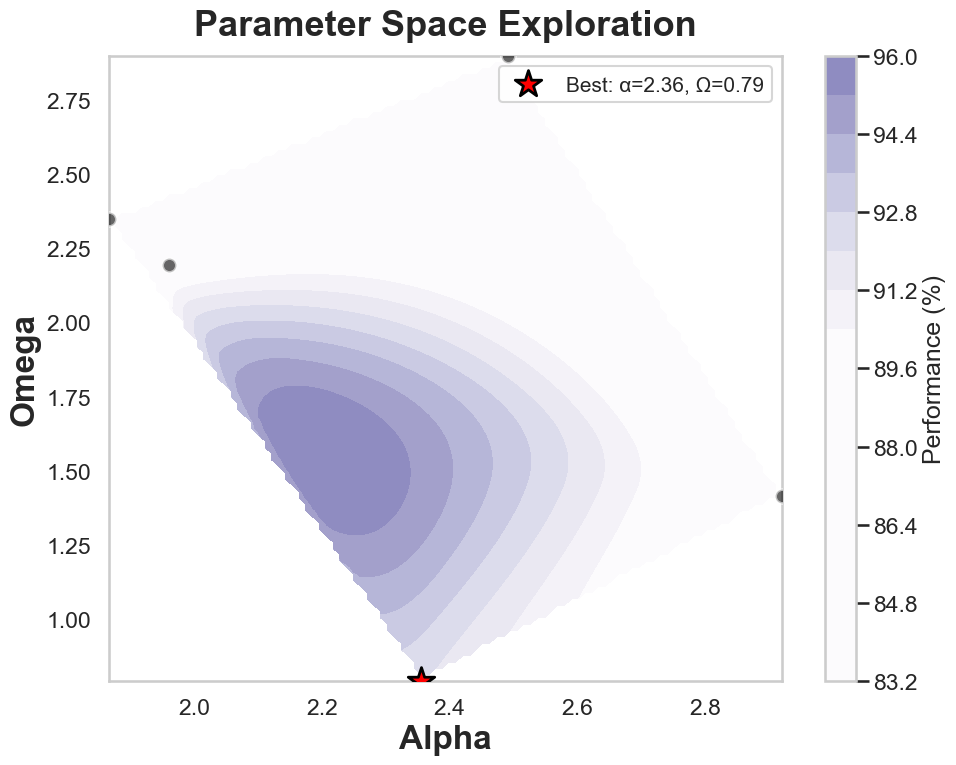

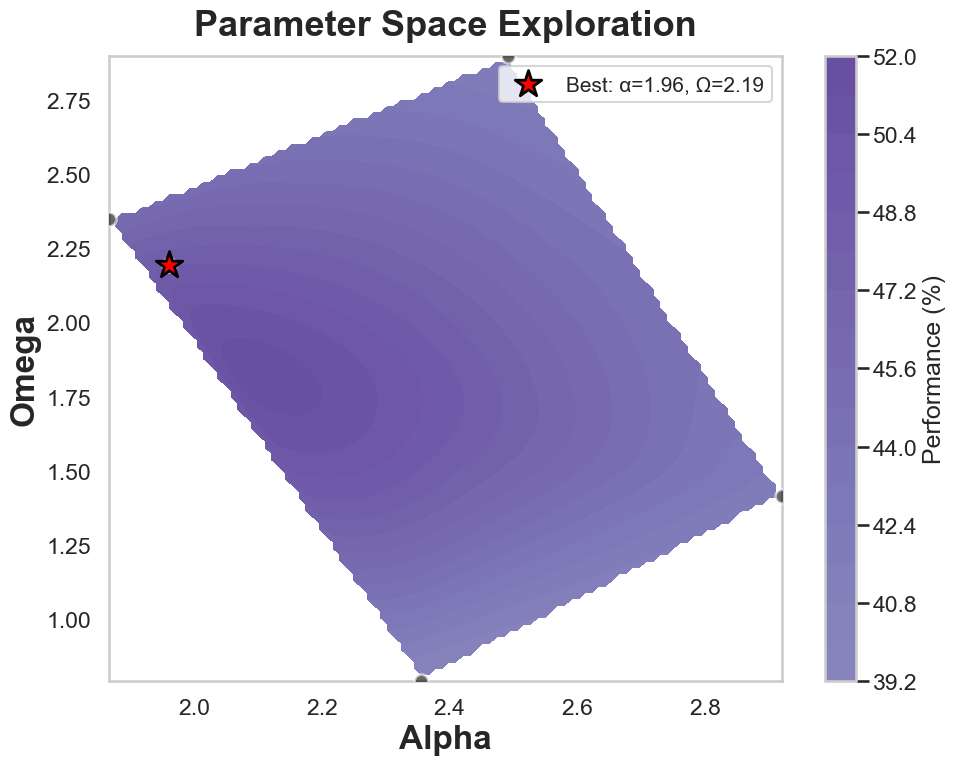

In [152]:

# ====================================================================================
# PARAMETER SPACE HEATMAP
# ====================================================================================

def plot_parameter_heatmap(sweep_df, metric_col, range = [70,100]):
    """Create heatmap of parameter space"""
    import os
    os.makedirs('plots', exist_ok=True)
    
    plt.figure(figsize=(10, 8))
    
    from scipy.interpolate import griddata
    
    alpha_vals = sweep_df['alpha'].values
    omega_vals = sweep_df['omega'].values
    metric_vals = sweep_df[metric_col].values * 100
    
    # Create grid
    alpha_grid = np.linspace(alpha_vals.min(), alpha_vals.max(), 100)
    omega_grid = np.linspace(omega_vals.min(), omega_vals.max(), 100)
    alpha_mesh, omega_mesh = np.meshgrid(alpha_grid, omega_grid)
    
    # Interpolate
    metric_mesh = griddata(
        (alpha_vals, omega_vals), 
        metric_vals, 
        (alpha_mesh, omega_mesh), 
        method='cubic'
    )
    
    # Plot heatmap
    im = plt.contourf(alpha_mesh, omega_mesh, metric_mesh, levels=15, cmap='Purples', vmin=range[0], vmax=range[1])
    plt.colorbar(im, label='Performance (%)')
    
    # Overlay actual data points
    plt.scatter(alpha_vals, omega_vals, c='black', s=100, 
               edgecolors='white', linewidth=2, alpha=0.6, zorder=10)
    
    # Mark best point
    best_idx = sweep_df[metric_col].idxmax()
    best = sweep_df.iloc[best_idx]
    plt.scatter(best['alpha'], best['omega'], c='red', s=400, 
               marker='*', edgecolors='black', linewidth=2, 
               label=f'Best: α={best["alpha"]:.2f}, Ω={best["omega"]:.2f}', zorder=11)
    
    plt.xlabel('Alpha', fontsize=24, fontweight='bold')
    plt.ylabel('Omega', fontsize=24, fontweight='bold')
    plt.title('Parameter Space Exploration', fontsize=26, fontweight='bold', pad=15)
    plt.legend(fontsize=15, frameon=True, loc='best')
    plt.grid(alpha=0.3, color='white', linewidth=0.5)
    plt.tight_layout()
    plt.show()


##### use it!!!

plot_parameter_heatmap(sweep_df , metric_col1, range = [90, 100])
plot_parameter_heatmap(sweep_df , 'f1_hier', range=[-5, 70])

In [153]:
# ====================================================================================
# PLOTTING HELPER
# ====================================================================================

def create_bar_plot(data_flat, data_hier, title, ylabel, optimal_line=None, line_label='Optimal',
                   color_flat='#FFA500', color_hier='#7C3AED', show_points=True, 
                   use_ci=True, show_ci_shade=False, ci_alpha=0.15, show_stats = False):
    """
    Create a bar plot comparing flat vs hierarchical model performance.
    
    Args:
        data_flat: Array of flat model values
        data_hier: Array of hierarchical model values
        title: Plot title
        ylabel: Y-axis label
        optimal_line: If not None, draw horizontal reference line at this value, can also be the chance line
        line_label: Label for optimal line
        color_flat: Color for flat model bars
        color_hier: Color for hierarchical model bars
        show_points: If True, show individual data points
        use_ci: If True, use 95% CI; if False, use SEM
        show_ci_shade: If True, add shaded CI regions behind bars
        ci_alpha: Transparency of CI shading (default: 0.15)
    """
    fig, ax = plt.subplots(figsize=(6, 8))
    
    # Compute statistics
    flat_mean = np.mean(data_flat)
    hier_mean = np.mean(data_hier)
    flat_sem = stats.sem(data_flat)
    hier_sem = stats.sem(data_hier)
    
    # Compute error bars based on use_ci
    if use_ci:
        flat_err = 1.96 * flat_sem
        hier_err = 1.96 * hier_sem
        error_type = '95% CI'
    else:
        flat_err = flat_sem
        hier_err = hier_sem
        error_type = 'SEM'
    
    data = {
        'Model': ['Flat', 'HOLMES'], 
        'Mean': [flat_mean, hier_mean], 
        'Error': [flat_err, hier_err]
    }
    df = pd.DataFrame(data)
    
    # Add shaded CI regions if requested (behind bars)
    if show_ci_shade:
        # Flat shaded region
        flat_rect = plt.Rectangle(
            (-0.4, flat_mean - flat_err),
            0.8,
            2 * flat_err,
            facecolor=color_flat,
            alpha=ci_alpha,
            edgecolor='none',
            zorder=1
        )
        ax.add_patch(flat_rect)
        
        # Hier shaded region
        hier_rect = plt.Rectangle(
            (0.6, hier_mean - hier_err),
            0.8,
            2 * hier_err,
            facecolor=color_hier,
            alpha=ci_alpha,
            edgecolor='black',
            zorder=1
        )
        ax.add_patch(hier_rect)
    
    # Create bar plot
    bars = ax.bar(df['Model'], df['Mean'], yerr=df['Error'],
                  color=[color_flat, color_hier], capsize=6,
                  edgecolor='black', linewidth=2, alpha=0.8,
                  error_kw={'linewidth': 2}, zorder=5)
    
    # Add individual points if enabled
    if show_points:
        np.random.seed(42)
        x_flat = np.random.normal(0, 0.05, len(data_flat))
        ax.scatter(x_flat, data_flat, color=color_flat, s=30, alpha=0.3,
                  edgecolors='white', linewidth=0.5, zorder=10)
        
        x_hier = np.random.normal(1, 0.05, len(data_hier))
        ax.scatter(x_hier, data_hier, color=color_hier, s=30, alpha=0.3,
                  edgecolors='white', linewidth=0.5, zorder=10)
    
    # # Add value labels on bars
    # for i, (bar, mean) in enumerate(zip(bars, df['Mean'])):
    #     height = bar.get_height()
    #     if height > 0.2:
    #         ax.text(bar.get_x() + bar.get_width() / 2., height - 0.1, 
    #                f'{height:.2f}', 
    #                ha='center', va='center', color='white', 
    #                fontsize=25, fontweight='bold')
    #     else:
    #         ax.text(bar.get_x() + bar.get_width() / 2., height + 0.2, 
    #                f'{height:.2f}', 
    #                ha='center', va='bottom', 
    #                fontsize=25, fontweight='bold')
    
    # Statistical test
    t_stat, p_val = stats.ttest_rel(data_hier, data_flat)
    print(f"\nStatistics for '{title}':")
    print(f"  Flat:  {flat_mean:.2f} ± {flat_err:.2f} ({error_type})")
    print(f"  Hier:  {hier_mean:.2f} ± {hier_err:.2f} ({error_type})")
    print(f"  Diff:  {hier_mean - flat_mean:+.2f}")
    print(f"  t({len(data_flat)-1}) = {t_stat:.3f}, p = {p_val:.2e}")
    
    if show_stats: 
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
        y_max = max(df['Mean'] + df['Error']) + 0.3
        
        # Draw significance bracket
        ax.plot([0, 0, 1, 1], [y_max, y_max + 0.1, y_max + 0.1, y_max],
                'k-', linewidth=2, clip_on=False, zorder=15)
        
        # Add significance text
        if sig != 'n.s.':
            ax.text(0.5, y_max + 0.15, sig, ha='center', va='bottom',
                    fontsize=33, fontweight='bold', clip_on=False, zorder=15)
        else:
            ax.text(0.5, y_max + 0.15, sig, ha='center', va='bottom',
                    fontsize=20, fontweight='bold', clip_on=False, zorder=15)
    
    # Add optimal reference line if specified
    if optimal_line is not None:
        ax.axhline(optimal_line, color='red', linestyle='--', linewidth=2, alpha=0.7,
                   label=line_label, zorder=2)
    
    # Labels and formatting
    ax.set_title('', fontsize=40, fontweight='bold', pad=40)
    ax.set_ylabel(ylabel, fontsize=28, fontweight='bold')
    ax.tick_params(axis='x', labelsize=25)
    ax.tick_params(axis='y', labelsize=25)
    ax.grid(alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Legend
    legend_elements = []
    if optimal_line is not None:
        legend_elements.append(plt.Line2D([0], [0], color='red', linestyle='--', 
                                         linewidth=3, label=line_label))
    
    if show_ci_shade:
        legend_elements.append(plt.Rectangle((0, 0), 1, 1, fc=color_flat, 
                                            alpha=ci_alpha, label=f'{error_type} (shaded)'))
    
    if legend_elements:
        ax.legend(handles=legend_elements, fontsize=20, loc='best')
    
    # # Add note about error bars
    # error_note = f'Error bars: {error_type}'
    # if show_ci_shade:
    #     error_note += f'\nShaded regions: {error_type}'
    # ax.text(0.98, 0.02, error_note,
    #         transform=ax.transAxes, fontsize=11,
    #         verticalalignment='bottom', horizontalalignment='right',
    #         style='italic',
    #         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()



### task accuracy


Statistics for '2-Level Task: Outcome Prediction':
  Flat:  96.25 ± 1.18 (95% CI)
  Hier:  87.04 ± 3.24 (95% CI)
  Diff:  -9.21
  t(4) = -7.725, p = 1.51e-03


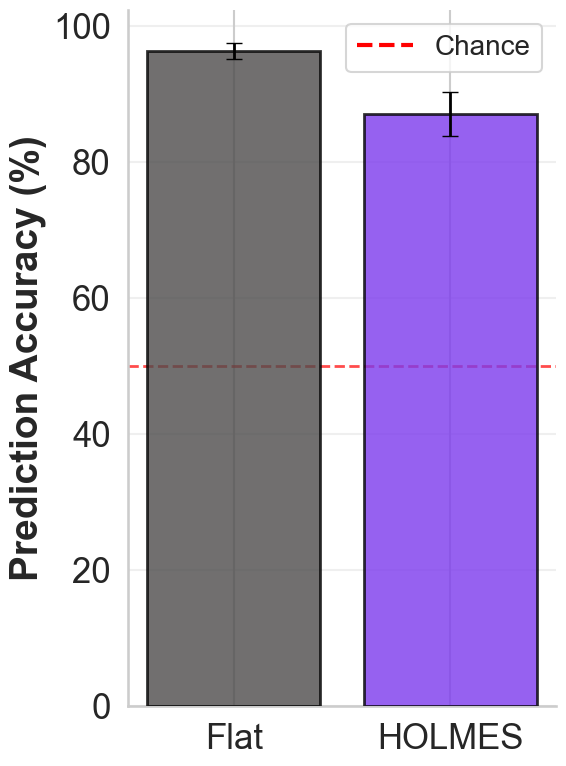


Statistics for '3-Level Task: Outcome Prediction':
  Flat:  87.46 ± 4.84 (95% CI)
  Hier:  79.33 ± 3.36 (95% CI)
  Diff:  -8.12
  t(4) = -7.957, p = 1.35e-03


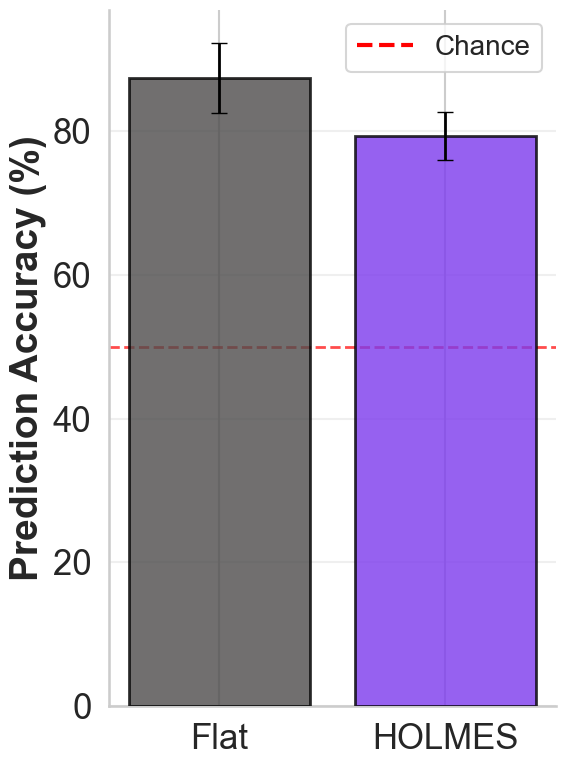


Statistics for '4-Level Task: Outcome Prediction':
  Flat:  81.76 ± 2.53 (95% CI)
  Hier:  74.99 ± 0.28 (95% CI)
  Diff:  -6.77
  t(4) = -5.829, p = 4.32e-03


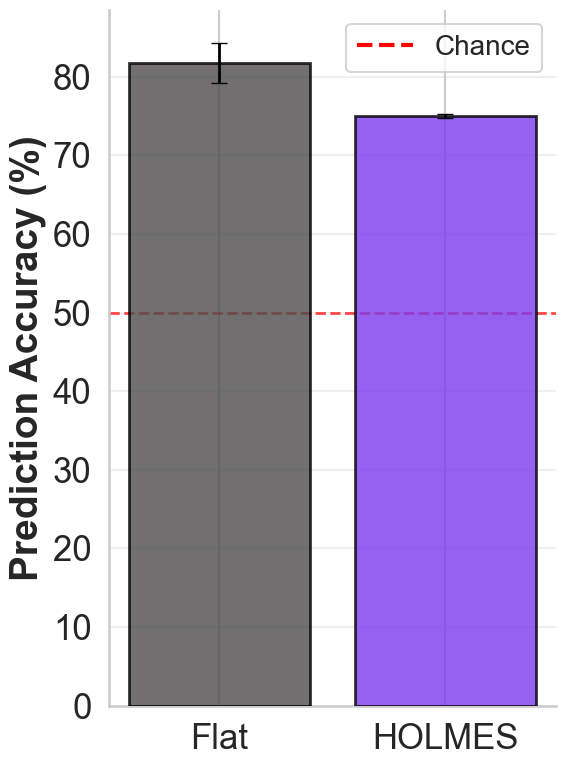


Statistics for '5-Level Task: Outcome Prediction':
  Flat:  81.69 ± 4.50 (95% CI)
  Hier:  75.42 ± 0.39 (95% CI)
  Diff:  -6.27
  t(4) = -2.740, p = 5.19e-02


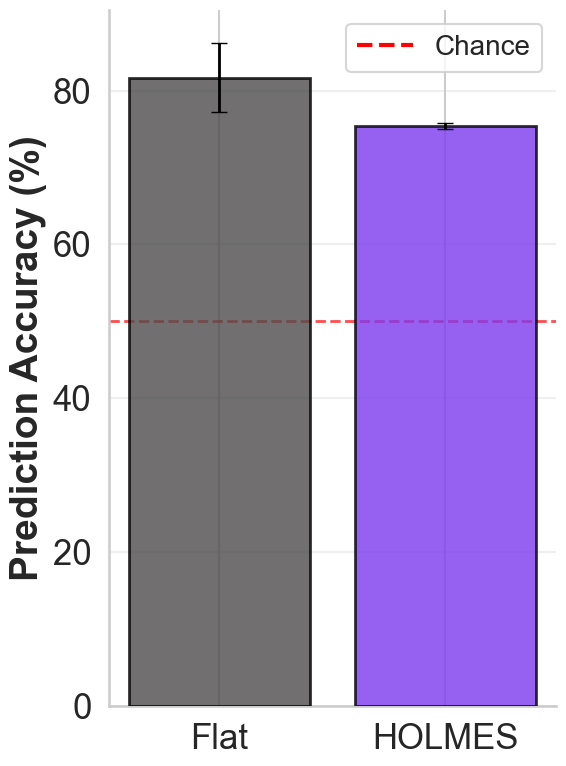


 Using pre-computed asymptotic accuracy

ASYMPTOTIC ACCURACY (final 70% of trials)
Data source: pre-computed asymptotic accuracy
Error bars: 95% CI

2-Level Task (n=5):
  Flat:         100.0% ± 0.0% (95% CI: ±0.0%)
  Hierarchical: 98.9% ± 1.1% (95% CI: ±1.1%)
  Difference:   -1.1%
  Statistics:
    t(4) = -2.018, p = 1.14e-01
    Cohen's d = -0.902 (large effect)
    95% CI of difference: [-2.1%, -0.0%]

3-Level Task (n=5):
  Flat:         91.6% ± 5.3% (95% CI: ±5.2%)
  Hierarchical: 83.5% ± 4.4% (95% CI: ±4.4%)
  Difference:   -8.0%
  Statistics:
    t(4) = -11.992, p = 2.77e-04
    Cohen's d = -5.363 (large effect)
    95% CI of difference: [-9.4%, -6.7%]

4-Level Task (n=5):
  Flat:         84.1% ± 3.2% (95% CI: ±3.1%)
  Hierarchical: 75.3% ± 0.3% (95% CI: ±0.3%)
  Difference:   -8.7%
  Statistics:
    t(4) = -5.932, p = 4.05e-03
    Cohen's d = -2.653 (large effect)
    95% CI of difference: [-11.6%, -5.8%]

5-Level Task (n=5):
  Flat:         83.5% ± 5.4% (95% CI: ±5.3%)
  Hierar

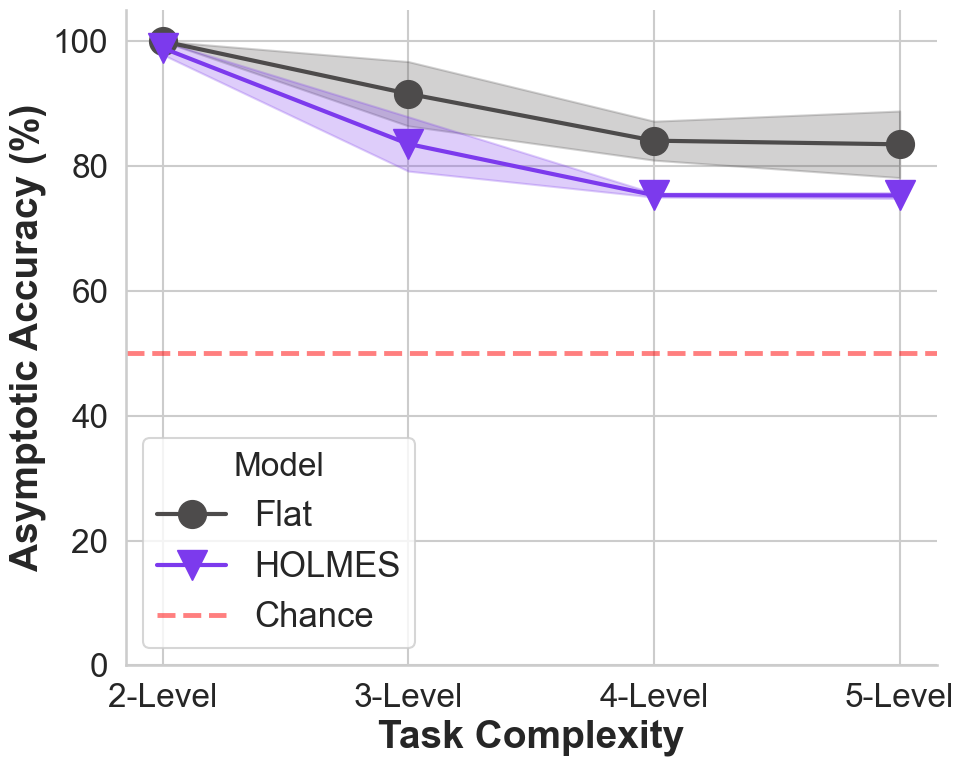

In [154]:

def plot_outcome_prediction(all_results_df, show_points=True, use_ci = True, title = ''):
    """Bar chart for outcome prediction accuracy across task levels using helper function
    
    Args:
        all_results_df: DataFrame with results
        save_path: Path to save figure
        show_points: If True, show individual data points on bars
    """
    import os
    os.makedirs('plots', exist_ok=True)
    
    COLOR_FLAT = "#4D4B4B"
    COLOR_HIER = '#7C3AED'
    
    # Create separate bar chart for each complexity level
    for n_levels in range(2, 6):
        df_n = all_results_df[all_results_df['n_levels'] == n_levels]
        
        if 'flat_outcome_acc' in df_n.columns and 'hier_outcome_acc' in df_n.columns:
            flat_vals = df_n['flat_outcome_acc'].dropna().values * 100
            hier_vals = df_n['hier_outcome_acc'].dropna().values * 100
            
            if len(flat_vals) > 0 and len(hier_vals) > 0:
                create_bar_plot(
                    data_flat=flat_vals,
                    data_hier=hier_vals,
                    title=f'{n_levels}-Level Task: Outcome Prediction',
                    ylabel='Prediction Accuracy (%)',
                    optimal_line=50,  # Chance level
                    line_label='Chance',
                    color_flat=COLOR_FLAT,
                    color_hier=COLOR_HIER,
                    show_points=show_points,
                    use_ci=use_ci
                )
    plt.show()


def plot_outcome_prediction_line_asymptotic(all_results_df, 
                                           save_path='plots/outcome_prediction_asymptotic.png',
                                           show_points=False,
                                           asymptote_window=0.5,
                                           use_ci=True):  
    """
    Line plot for ASYMPTOTIC outcome prediction accuracy across task levels.
    
    Works with either:
    1. Raw data with traces (computes asymptotic accuracy on the fly)
    2. Aggregated data with pre-computed asymptotic accuracy
    
    Args:
        all_results_df: DataFrame with results
        save_path: Path to save figure
        show_points: If True, show individual data points (parameter combinations)
        asymptote_window: Fraction of final trials to average (default: 0.5 = last 50%)
        use_ci: If True, use 95% CI; if False, use SEM (default: True)
    """
    import os
    os.makedirs('plots', exist_ok=True)
    
    COLOR_FLAT = "#4D4B4B"
    COLOR_HIER = '#7C3AED'
    
    sns.set_style("whitegrid")
    sns.set_context("talk")
    
    fig, ax = plt.subplots(figsize=(10, 8))
    error_type = "95% CI" if use_ci else "SEM"
    
    # ========================================================================
    # Check if we have pre-computed asymptotic accuracy or need to compute it
    # ========================================================================
    
    has_precomputed = 'flat_asymptotic_acc' in all_results_df.columns
    has_traces = 'flat_outcome_trace' in all_results_df.columns
    
    if not has_precomputed and not has_traces:
        print(" ERROR: DataFrame has neither traces nor pre-computed asymptotic accuracy!")
        print("Available columns:", all_results_df.columns.tolist()[:20])
        return
    
    data_source = "pre-computed asymptotic accuracy" if has_precomputed else "traces"
    print(f"\n Using {data_source}")
    
    # Helper function to compute asymptotic accuracy from trace (only if needed)
    def compute_asymptotic_accuracy(trace, window=0.5):
        if isinstance(trace, str):
            import ast
            trace = ast.literal_eval(trace)
        
        trace = np.array(trace)
        n_trials = len(trace)
        
        if n_trials == 0:
            return np.nan
        
        window_start = max(0, int(n_trials * (1 - window)))
        asymptote_acc = np.mean(trace[window_start:]) * 100
        
        return asymptote_acc
    
    def cohens_d_paired(a, b):
        diff = np.array(a) - np.array(b)
        return np.mean(diff) / np.std(diff, ddof=1)
    
    # ========================================================================
    # Collect asymptotic accuracy values per level
    # ========================================================================
    
    levels = []
    flat_means, flat_errs = [], []
    hier_means, hier_errs = [], []
    flat_all, hier_all = {}, {}

    for n_levels in range(2, 6):
        df_n = all_results_df[all_results_df['n_levels'] == n_levels]
        
        if len(df_n) == 0:
            continue
        
        flat_asymptotic = []
        hier_asymptotic = []
        
        if has_precomputed:
            # Use pre-computed values (from aggregated data)
            flat_asymptotic = (df_n['flat_asymptotic_acc'].dropna() * 100).tolist()
            hier_asymptotic = (df_n['hier_asymptotic_acc'].dropna() * 100).tolist()
            
        elif has_traces:
            # Compute from traces (from raw data)
            for idx, row in df_n.iterrows():
                flat_trace = row['flat_outcome_trace']
                hier_trace = row['hier_outcome_trace']
                
                flat_acc = compute_asymptotic_accuracy(flat_trace, window=asymptote_window)
                hier_acc = compute_asymptotic_accuracy(hier_trace, window=asymptote_window)
                
                if not np.isnan(flat_acc) and not np.isnan(hier_acc):
                    flat_asymptotic.append(flat_acc)
                    hier_asymptotic.append(hier_acc)
        
        flat_vals = np.array(flat_asymptotic)
        hier_vals = np.array(hier_asymptotic)

        if len(flat_vals) == 0:
            continue

        levels.append(n_levels)
        flat_means.append(np.mean(flat_vals))
        hier_means.append(np.mean(hier_vals))
        
        # Compute error bars (SEM or 95% CI)
        flat_sem = stats.sem(flat_vals)
        hier_sem = stats.sem(hier_vals)
        
        if use_ci:
            # 95% CI = 1.96 × SEM
            flat_errs.append(1.96 * flat_sem)
            hier_errs.append(1.96 * hier_sem)
        else:
            flat_errs.append(flat_sem)
            hier_errs.append(hier_sem)
        
        flat_all[n_levels] = flat_vals
        hier_all[n_levels] = hier_vals
    
    if len(levels) == 0:
        print("ERROR: No data to plot!")
        return

    levels = np.array(levels)
    flat_means = np.array(flat_means)
    flat_errs = np.array(flat_errs)
    hier_means = np.array(hier_means)
    hier_errs = np.array(hier_errs)

    # ========================================================================
    # Plot
    # ========================================================================
    
    # Shaded error bands
    ax.fill_between(levels, flat_means - flat_errs, flat_means + flat_errs,
                    color=COLOR_FLAT, alpha=0.25, label=f'_nolegend_')
    ax.fill_between(levels, hier_means - hier_errs, hier_means + hier_errs,
                    color=COLOR_HIER, alpha=0.25, label=f'_nolegend_')

    # Lines
    ax.plot(levels, flat_means, color=COLOR_FLAT, linewidth=3,
            marker='o', markersize=20, label='Flat', zorder=5)
    ax.plot(levels, hier_means, color=COLOR_HIER, linewidth=3,
            marker='v', markersize=21, label='HOLMES', zorder=5)

    # Individual points (jittered)
    if show_points:
        rng = np.random.default_rng(42)
        for i, n in enumerate(levels):
            x_jitter = rng.normal(0, 0.04, len(flat_all[n]))
            ax.scatter(n + x_jitter, flat_all[n], color=COLOR_FLAT,
                       s=40, alpha=0.4, edgecolors='white', linewidth=0.5, zorder=4)
            x_jitter = rng.normal(0, 0.04, len(hier_all[n]))
            ax.scatter(n + x_jitter, hier_all[n], color=COLOR_HIER,
                       s=40, alpha=0.4, edgecolors='white', linewidth=0.5, zorder=4)

    # ========================================================================
    # Print Statistics
    # ========================================================================
    
    print("\n" + "="*80)
    print(f"ASYMPTOTIC ACCURACY (final {int(asymptote_window*100)}% of trials)")
    print(f"Data source: {data_source}")
    print(f"Error bars: {error_type}")
    print("="*80)
    
    for i, n in enumerate(levels):
        fv = flat_all[n]
        hv = hier_all[n]
        
        print(f"\n{n}-Level Task (n={len(fv)}):")
        print(f"  Flat:         {np.mean(fv):.1f}% ± {np.std(fv):.1f}% ({error_type}: ±{flat_errs[i]:.1f}%)")
        print(f"  Hierarchical: {np.mean(hv):.1f}% ± {np.std(hv):.1f}% ({error_type}: ±{hier_errs[i]:.1f}%)")
        print(f"  Difference:   {np.mean(hv) - np.mean(fv):+.1f}%")
        
        if len(fv) > 1 and len(hv) > 1:
            t, p_val = stats.ttest_rel(hv, fv)
            d = cohens_d_paired(hv, fv)
            
            effect_interp = ("negligible" if abs(d) < 0.2 else 
                           "small" if abs(d) < 0.5 else 
                           "medium" if abs(d) < 0.8 else "large")
            
            print(f"  Statistics:")
            print(f"    t({len(fv)-1}) = {t:.3f}, p = {p_val:.2e}")
            print(f"    Cohen's d = {d:+.3f} ({effect_interp} effect)")
            
            diff_ci = 1.96 * stats.sem(hv - fv)
            print(f"    95% CI of difference: [{np.mean(hv-fv) - diff_ci:.1f}%, "
                  f"{np.mean(hv-fv) + diff_ci:.1f}%]")

    # Summary table
    print("\n" + "="*80)
    print("SUMMARY TABLE")
    print("="*80)
    print(f"{'Level':<8} {'Flat (%)':<18} {'Hier (%)':<18} {'Diff':<10} {'Cohen d':<10} {'p-value':<12}")
    print("-"*80)
    for i, n in enumerate(levels):
        fv = flat_all[n]
        hv = hier_all[n]
        if len(fv) > 1 and len(hv) > 1:
            t, p = stats.ttest_rel(hv, fv)
            d = cohens_d_paired(hv, fv)
            diff = np.mean(hv) - np.mean(fv)
            
            p_str = f"{p:.2e}" if p < 0.001 else f"{p:.3f}"
            print(f"{n}-Level  {np.mean(fv):5.1f}±{flat_errs[i]:4.1f}    "
                  f"{np.mean(hv):5.1f}±{hier_errs[i]:4.1f}    "
                  f"{diff:+5.1f}%    {d:+6.3f}     {p_str}")
    print("="*80 + "\n")

    # ========================================================================
    # Formatting
    # ========================================================================
    
    # Chance line
    ax.axhline(50, color='red', linestyle='--', linewidth=3.5,
               alpha=0.5, zorder=1, label='Chance')

    ax.set_xticks(levels)
    ax.set_xticklabels([f'{n}-Level' for n in levels])
    ax.set_xlabel('Task Complexity', fontsize=28, fontweight='bold')
    ax.set_ylabel('Asymptotic Accuracy (%)', fontsize=28, fontweight='bold')
    ax.tick_params(axis='both', labelsize=24)
    
    # Update legend to show error bar type
    ax.legend(title='Model', fontsize=25, title_fontsize=24, frameon=True, loc='lower left')
    
    ax.set_ylim([0, 105])

    # # Add text annotation
    # ax.text(0.98, 0.02, f'Asymptote: final {int(asymptote_window*100)}% of trials\nShaded Errors: {error_type}',
    #         transform=ax.transAxes, ha='right', va='bottom',
    #         fontsize=14, style='italic', color='gray')

    sns.despine()
    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    print(f"\n✓ Saved to {save_path}\n")
    plt.show()




## use it 
plot_outcome_prediction(all_results_df, show_points=False, use_ci =True)
plot_outcome_prediction_line_asymptotic(all_results_df, asymptote_window=0.7,use_ci=True)


2-LEVEL TASK SUMMARY (Moving Avg (w=20)):
  Total trials: 80
  Smoothing: Moving Avg (w=20)
  Smoothed trace length: 61 (reduced by 19)
  Asymptote window: trials 64-80 (16 trials)
  Flat asymptotic accuracy: 100.0%
  Hier asymptotic accuracy: 99.2%
  Difference: -0.8%
  ✗ Flat remains ahead by end (smoothed)
     (but gap is closing: 11.2% → 0.7%)


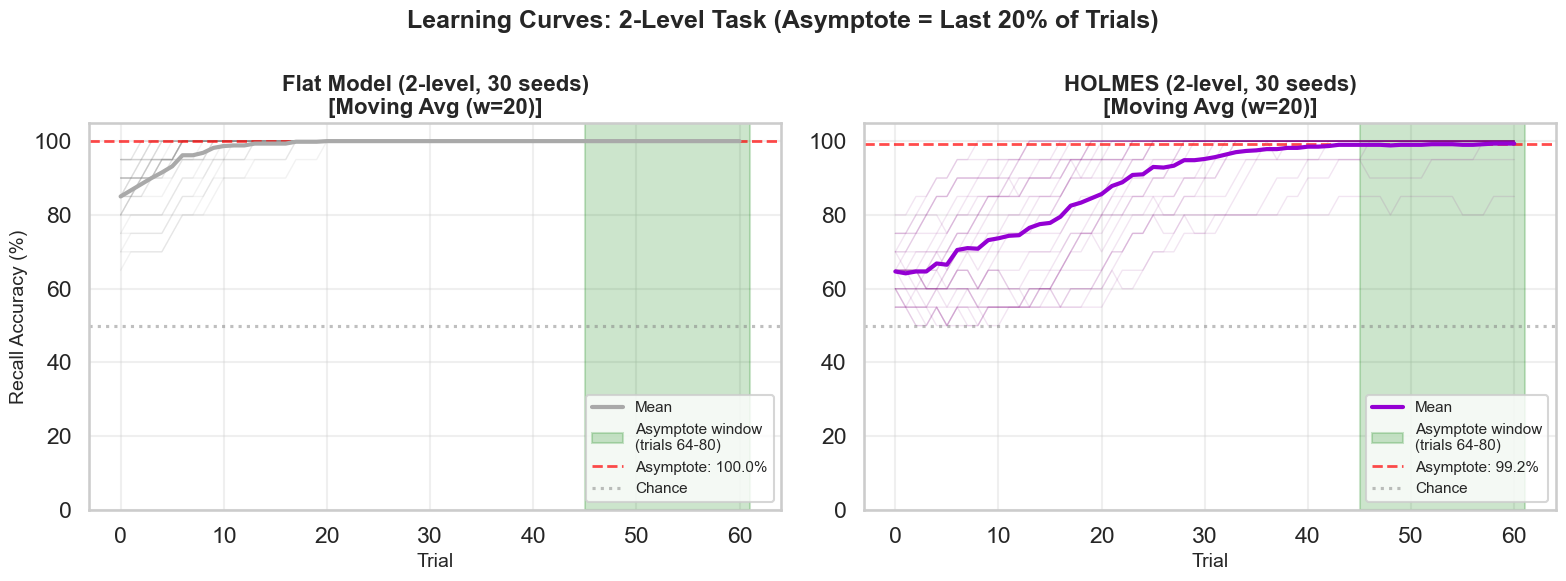


3-LEVEL TASK SUMMARY (Moving Avg (w=20)):
  Total trials: 160
  Smoothing: Moving Avg (w=20)
  Smoothed trace length: 141 (reduced by 19)
  Asymptote window: trials 128-160 (32 trials)
  Flat asymptotic accuracy: 92.6%
  Hier asymptotic accuracy: 82.7%
  Difference: -9.9%
  ✗ Flat remains ahead by end (smoothed)


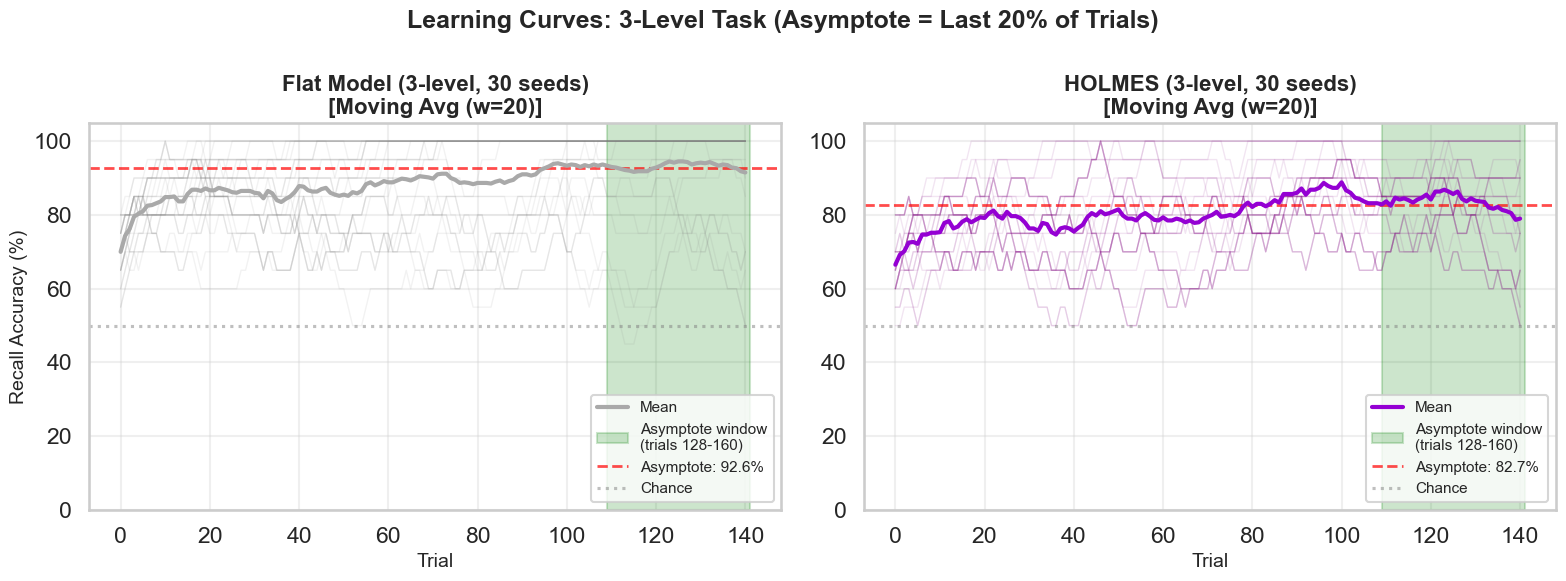


4-LEVEL TASK SUMMARY (Moving Avg (w=20)):
  Total trials: 320
  Smoothing: Moving Avg (w=20)
  Smoothed trace length: 301 (reduced by 19)
  Asymptote window: trials 256-320 (64 trials)
  Flat asymptotic accuracy: 84.6%
  Hier asymptotic accuracy: 74.9%
  Difference: -9.6%
  ✗ Flat remains ahead by end (smoothed)


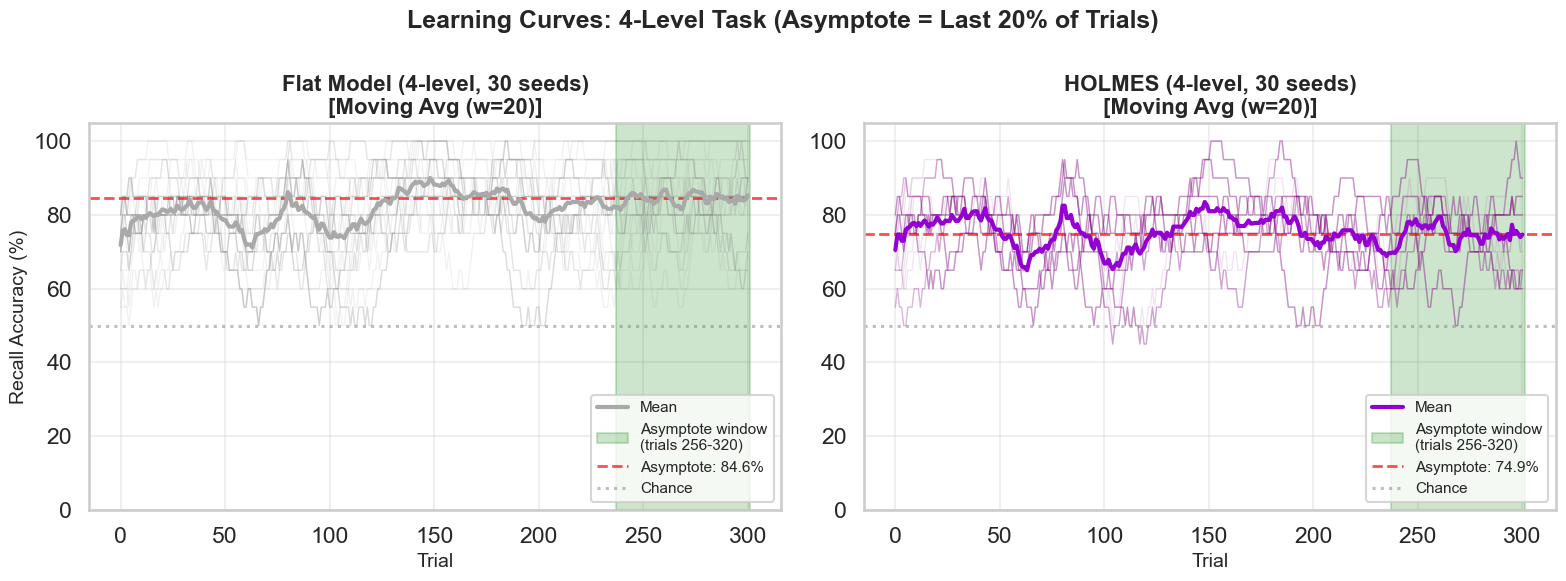


5-LEVEL TASK SUMMARY (Moving Avg (w=20)):
  Total trials: 640
  Smoothing: Moving Avg (w=20)
  Smoothed trace length: 621 (reduced by 19)
  Asymptote window: trials 512-640 (128 trials)
  Flat asymptotic accuracy: 83.1%
  Hier asymptotic accuracy: 74.1%
  Difference: -8.9%
  ✗ Flat remains ahead by end (smoothed)


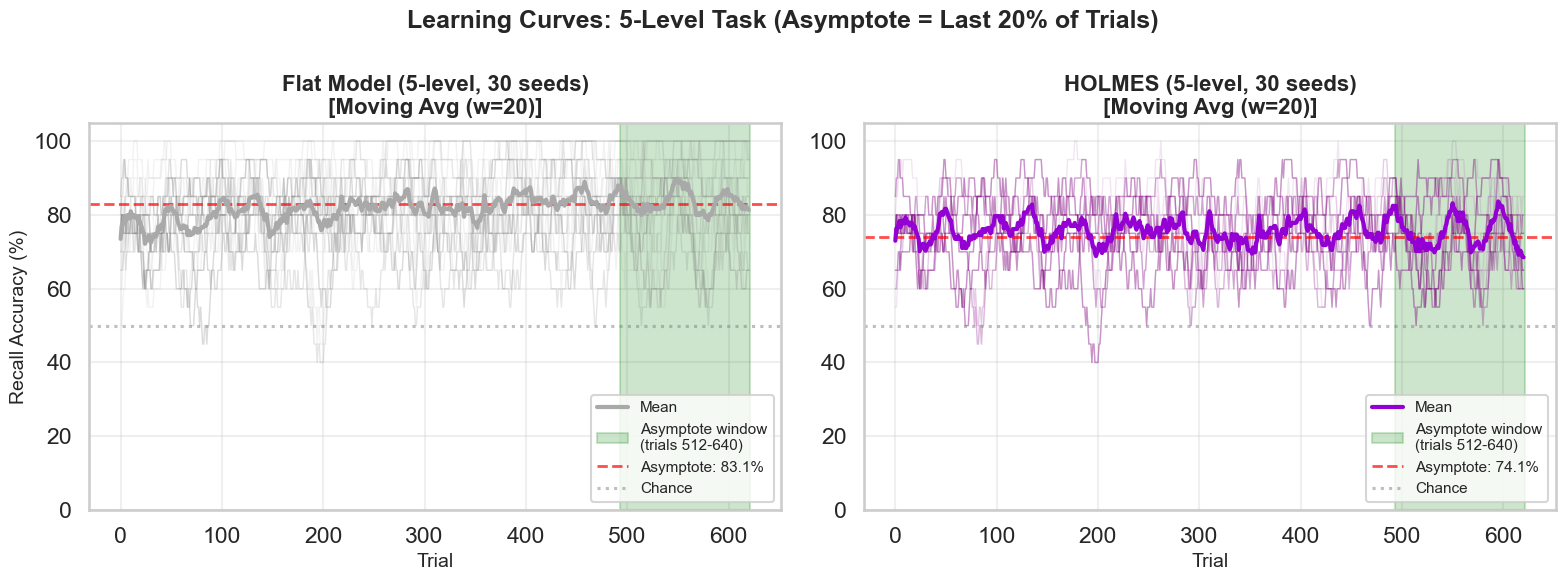

In [155]:
def plot_full_learning_curves(all_results_df, n_levels=4, n_seeds=20, 
                               smoothing=None, window_size=10):
    """
    Plot full learning curves to see learning dynamics.
    
    Args:
        all_results_df: DataFrame with results
        n_levels: Which task complexity to plot
        n_seeds: Number of seeds to show
        smoothing: Smoothing method. Options:
            None - raw trial-by-trial (default)
            'moving_average' - moving average
            'cumulative' - cumulative average
            'exponential' - exponential moving average
        window_size: Window size for moving average (default: 10)
    """
    df_n = all_results_df[all_results_df['n_levels'] == n_levels].head(n_seeds)
    
    if len(df_n) == 0:
        print(f"No data for {n_levels}-level task")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Helper to convert trace to array
    def get_trace(trace):
        if isinstance(trace, str):
            import ast
            return np.array(ast.literal_eval(trace))
        elif isinstance(trace, (list, np.ndarray)):
            return np.array(trace)
        else:
            return None
    
    # Smoothing functions
    def smooth_trace(trace, method=None, window=10):
        """Apply smoothing to a trace."""
        if method is None or len(trace) < window:
            return trace
        
        if method == 'moving_average':
            # Moving average
            return np.convolve(trace, np.ones(window)/window, mode='valid')
        
        elif method == 'cumulative':
            # Cumulative average
            return np.cumsum(trace) / np.arange(1, len(trace) + 1)
        
        elif method == 'exponential':
            # Exponential moving average
            alpha = 2 / (window + 1)
            ema = np.zeros_like(trace)
            ema[0] = trace[0]
            for i in range(1, len(trace)):
                ema[i] = alpha * trace[i] + (1 - alpha) * ema[i-1]
            return ema
        
        else:
            return trace
    
    flat_traces = []
    hier_traces = []
    flat_traces_raw = []
    hier_traces_raw = []
    
    for idx, row in df_n.iterrows():
        # Flat
        flat_trace = get_trace(row['flat_outcome_trace'])
        if flat_trace is not None:
            flat_traces_raw.append(flat_trace)
            smoothed = smooth_trace(flat_trace, method=smoothing, window=window_size)
            ax1.plot(smoothed * 100, alpha=0.1, color='gray', linewidth=1)
            flat_traces.append(smoothed)
        
        # Hierarchical
        hier_trace = get_trace(row['hier_outcome_trace'])
        if hier_trace is not None:
            hier_traces_raw.append(hier_trace)
            smoothed = smooth_trace(hier_trace, method=smoothing, window=window_size)
            ax2.plot(smoothed * 100, alpha=0.1, color='purple', linewidth=1)
            hier_traces.append(smoothed)
    
    if not flat_traces or not hier_traces:
        print("No valid traces found")
        return
    
    # Plot mean trajectory (of smoothed traces)
    flat_mean = np.mean(flat_traces, axis=0) * 100
    hier_mean = np.mean(hier_traces, axis=0) * 100
    
    ax1.plot(flat_mean, color='darkgray', linewidth=3, label='Mean', zorder=10)
    ax2.plot(hier_mean, color='darkviolet', linewidth=3, label='Mean', zorder=10)
    
    # Mark asymptote window (last 20%)
    # Use raw trace length for asymptote calculation
    n_trials_raw = len(flat_traces_raw[0])
    window_start_raw = int(n_trials_raw * 0.8)
    
    # Adjust for smoothed trace length if using moving average
    if smoothing == 'moving_average':
        n_trials = len(flat_traces[0])
        # Moving average reduces length by (window-1)
        offset = n_trials_raw - n_trials
        window_start = max(0, window_start_raw - offset)
    else:
        n_trials = len(flat_traces[0])
        window_start = window_start_raw
    
    ax1.axvspan(window_start, n_trials, alpha=0.2, color='green', 
                label=f'Asymptote window\n(trials {window_start_raw}-{n_trials_raw})')
    ax2.axvspan(window_start, n_trials, alpha=0.2, color='green',
                label=f'Asymptote window\n(trials {window_start_raw}-{n_trials_raw})')
    
    # Compute asymptotic performance from RAW traces (not smoothed)
    flat_asymptote = np.mean([np.mean(t[window_start_raw:]) for t in flat_traces_raw]) * 100
    hier_asymptote = np.mean([np.mean(t[window_start_raw:]) for t in hier_traces_raw]) * 100
    
    # Add horizontal lines showing asymptotic accuracy
    ax1.axhline(flat_asymptote, color='red', linestyle='--', linewidth=2, 
                alpha=0.7, label=f'Asymptote: {flat_asymptote:.1f}%')
    ax2.axhline(hier_asymptote, color='red', linestyle='--', linewidth=2,
                alpha=0.7, label=f'Asymptote: {hier_asymptote:.1f}%')
    
    # Formatting
    smoothing_label = {
        None: 'Raw',
        'moving_average': f'Moving Avg (w={window_size})',
        'cumulative': 'Cumulative Avg',
        'exponential': f'Exp Moving Avg (w={window_size})'
    }.get(smoothing, 'Unknown')
    
    ax1.set_title(f'Flat Model ({n_levels}-level, {len(flat_traces)} seeds)\n[{smoothing_label}]', 
                  fontsize=16, fontweight='bold')
    ax2.set_title(f'HOLMES ({n_levels}-level, {len(hier_traces)} seeds)\n[{smoothing_label}]', 
                  fontsize=16, fontweight='bold')
    
    ax1.set_ylabel('Recall Accuracy (%)', fontsize=14)
    ax1.set_xlabel('Trial', fontsize=14)
    ax2.set_xlabel('Trial', fontsize=14)
    
    ax1.set_ylim([0, 105])
    ax2.set_ylim([0, 105])
    
    ax1.axhline(50, color='gray', linestyle=':', alpha=0.5, label='Chance')
    ax2.axhline(50, color='gray', linestyle=':', alpha=0.5, label='Chance')
    
    ax1.legend(fontsize=11, frameon=True, loc='lower right')
    ax2.legend(fontsize=11, frameon=True, loc='lower right')
    
    ax1.grid(alpha=0.3)
    ax2.grid(alpha=0.3)
    
    plt.suptitle(f'Learning Curves: {n_levels}-Level Task (Asymptote = Last 20% of Trials)', 
                 fontsize=18, fontweight='bold')
    plt.tight_layout()
    
    # Print summary
    print(f"\n{n_levels}-LEVEL TASK SUMMARY ({smoothing_label}):")
    print(f"  Total trials: {n_trials_raw}")
    print(f"  Smoothing: {smoothing_label}")
    if smoothing == 'moving_average':
        print(f"  Smoothed trace length: {n_trials} (reduced by {n_trials_raw - n_trials})")
    print(f"  Asymptote window: trials {window_start_raw}-{n_trials_raw} ({n_trials_raw-window_start_raw} trials)")
    print(f"  Flat asymptotic accuracy: {flat_asymptote:.1f}%")
    print(f"  Hier asymptotic accuracy: {hier_asymptote:.1f}%")
    print(f"  Difference: {hier_asymptote - flat_asymptote:+.1f}%")
    
    # Check if hierarchical ever catches up
    if hier_mean[-1] > flat_mean[-1]:
        print(f"  ✓ Hierarchical surpasses flat by end (smoothed)")
    elif hier_mean[-1] < flat_mean[-1]:
        print(f"  ✗ Flat remains ahead by end (smoothed)")
        # Check if they're converging
        if len(flat_mean) > window_start:
            early_diff = flat_mean[window_start//2] - hier_mean[window_start//2]
            late_diff = flat_mean[-1] - hier_mean[-1]
            if abs(late_diff) < abs(early_diff):
                print(f"     (but gap is closing: {early_diff:.1f}% → {late_diff:.1f}%)")
    
    plt.show()



#### use it
for n_level in [2, 3, 4, 5]:
    plot_full_learning_curves(all_results_df1, n_levels=n_level, n_seeds=50,
                              smoothing='moving_average', window_size=20)

### scaling and efficiency

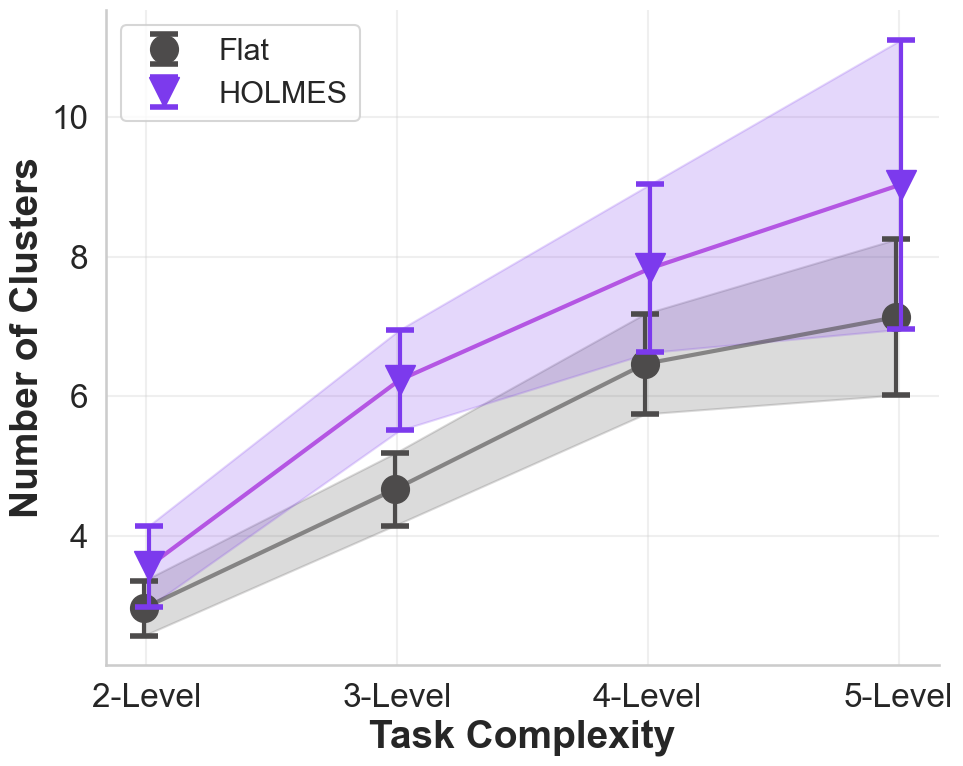


CLUSTER SCALING SUMMARY

2-Level Task:
  Flat:  3.0 ± 0.4 (95% CI)
  Hier:  3.6 ± 0.6 (95% CI)
  Diff:  +0.6 clusters (Hier - Flat)
  t(4) = 2.714, p = 5.33e-02 (n.s.)

3-Level Task:
  Flat:  4.7 ± 0.5 (95% CI)
  Hier:  6.2 ± 0.7 (95% CI)
  Diff:  +1.6 clusters (Hier - Flat)
  t(4) = 10.136, p = 5.33e-04 (***)

4-Level Task:
  Flat:  6.5 ± 0.7 (95% CI)
  Hier:  7.8 ± 1.2 (95% CI)
  Diff:  +1.4 clusters (Hier - Flat)
  t(4) = 3.393, p = 2.74e-02 (*)

5-Level Task:
  Flat:  7.1 ± 1.1 (95% CI)
  Hier:  9.0 ± 2.1 (95% CI)
  Diff:  +1.9 clusters (Hier - Flat)
  t(4) = 3.594, p = 2.29e-02 (*)



In [156]:
def plot_clusters_scaling(all_results_df, save_path='plots/clusters_scaling.png', 
                          show_points=True, show_ci=True, use_ci=True, ci_alpha=0.15):
    """
    Number of clusters across task complexities with confidence intervals.
    
    Args:
        all_results_df: DataFrame with results
        save_path: Path to save figure
        show_points: If True, show individual data points with jitter
        show_ci: If True, show shaded confidence interval regions
        use_ci: If True, use 95% CI for error bars; if False, use SEM
        ci_alpha: Transparency of CI shading (default: 0.15)
    """
    import os
    os.makedirs('plots', exist_ok=True)
    
    sns.set_style("whitegrid")
    sns.set_context("talk")
    
    COLOR_FLAT = "#4D4B4B"
    COLOR_HIER = '#7C3AED'
    COLOR_OPTIMAL = '#10B981'
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    level_names = {2: 'species', 3: 'prep', 4: 'storage', 5: 'season'}
    
    levels = []
    flat_all_points = []
    hier_all_points = []
    flat_means = []
    hier_means = []
    flat_errs = []
    hier_errs = []
    flat_ci_lower = []
    flat_ci_upper = []
    hier_ci_lower = []
    hier_ci_upper = []
    true_labels_list = []
    
    for n_levels in range(2, 6):
        df_n = all_results_df[all_results_df['n_levels'] == n_levels]
        top_name = level_names.get(n_levels)
        
        if len(df_n) == 0:
            continue
        
        # Check for new naming with level prefix
        flat_col = f'{top_name}_flat_n_clusters' if top_name and f'{top_name}_flat_n_clusters' in df_n.columns else 'flat_n_clusters'
        hier_col = f'{top_name}_hier_n_clusters' if top_name and f'{top_name}_hier_n_clusters' in df_n.columns else 'hier_n_clusters'
        labels_col = f'{top_name}_flat_n_labels' if top_name and f'{top_name}_flat_n_labels' in df_n.columns else 'flat_n_labels'
        
        if flat_col in df_n.columns and hier_col in df_n.columns:
            # Get seeds with both values
            has_flat = df_n[flat_col].notna()
            has_hier = df_n[hier_col].notna()
            valid_seeds = has_flat & has_hier
            
            if valid_seeds.sum() > 0:
                flat_vals = df_n.loc[valid_seeds, flat_col].values
                hier_vals = df_n.loc[valid_seeds, hier_col].values
                n_labels = df_n[labels_col].dropna().mean() if labels_col in df_n.columns else None
                
                # Compute statistics
                flat_mean = np.mean(flat_vals)
                hier_mean = np.mean(hier_vals)
                
                flat_sem = stats.sem(flat_vals)
                hier_sem = stats.sem(hier_vals)
                
                if use_ci:
                    # 95% CI = 1.96 * SEM
                    flat_err = 1.96 * flat_sem
                    hier_err = 1.96 * hier_sem
                else:
                    # Just SEM
                    flat_err = flat_sem
                    hier_err = hier_sem
                
                levels.append(n_levels)
                flat_all_points.append(flat_vals)
                hier_all_points.append(hier_vals)
                flat_means.append(flat_mean)
                hier_means.append(hier_mean)
                flat_errs.append(flat_err)
                hier_errs.append(hier_err)
                
                # Store CI bounds for shading
                flat_ci_lower.append(flat_mean - flat_err)
                flat_ci_upper.append(flat_mean + flat_err)
                hier_ci_lower.append(hier_mean - hier_err)
                hier_ci_upper.append(hier_mean + hier_err)
                
                if n_labels is not None:
                    true_labels_list.append(n_labels)
    
    if len(levels) == 0:
        print("No data to plot")
        return
    
    # Convert to arrays for easier plotting
    levels = np.array(levels)
    flat_means = np.array(flat_means)
    hier_means = np.array(hier_means)
    flat_errs = np.array(flat_errs)
    hier_errs = np.array(hier_errs)
    flat_ci_lower = np.array(flat_ci_lower)
    flat_ci_upper = np.array(flat_ci_upper)
    hier_ci_lower = np.array(hier_ci_lower)
    hier_ci_upper = np.array(hier_ci_upper)
    
    # X positions for flat and hierarchical (slightly offset)
    flat_x_positions = levels - 0.01
    hier_x_positions = levels + 0.01
    
    # Plot shaded confidence intervals FIRST (lowest z-order)
    if show_ci:
        ax.fill_between(flat_x_positions, flat_ci_lower, flat_ci_upper,
                        color=COLOR_FLAT, alpha=ci_alpha, 
                        label='_nolegend_', zorder=1)
        ax.fill_between(hier_x_positions, hier_ci_lower, hier_ci_upper,
                        color=COLOR_HIER, alpha=ci_alpha,
                        label='_nolegend_', zorder=2)
    
    # Plot individual points if enabled
    if show_points:
        np.random.seed(42)
        jitter_amount = 0.08
        
        for i, level in enumerate(levels):
            # Flat points
            x_flat = np.random.normal(level - 0.1, jitter_amount, len(flat_all_points[i]))
            ax.scatter(x_flat, flat_all_points[i], 
                      color=COLOR_FLAT, s=60, alpha=0.3, 
                      edgecolors='none', zorder=5)
            
            # Hierarchical points
            x_hier = np.random.normal(level + 0.1, jitter_amount, len(hier_all_points[i]))
            ax.scatter(x_hier, hier_all_points[i], 
                      color=COLOR_HIER, s=60, alpha=0.3, 
                      edgecolors='none', zorder=6)
    
    # Plot connecting lines between means
    ax.plot(flat_x_positions, flat_means, '-', 
           color=COLOR_FLAT, linewidth=3, alpha=0.6, zorder=7)
    ax.plot(hier_x_positions, hier_means, '-', 
           color='darkviolet', linewidth=3, alpha=0.6, zorder=8)
    
    # Plot means with error bars
    error_label = '95% CI' if use_ci else 'SEM'
    
    ax.errorbar(flat_x_positions, flat_means, 
               yerr=flat_errs,
               fmt='o', markersize=20, capsize=10, capthick=4,
               color=COLOR_FLAT, linewidth=4, elinewidth=3,
               label='Flat', zorder=10)
    
    ax.errorbar(hier_x_positions, hier_means, 
               yerr=hier_errs,
               fmt='v', markersize=21, capsize=10, capthick=4,
               color=COLOR_HIER, linewidth=4, elinewidth=3,
               label='HOLMES', zorder=11)
    
    # Plot optimal line (if you want to show true number of labels)
    # if len(true_labels_list) > 0:
    #     ax.plot(levels, true_labels_list, '--', 
    #            color=COLOR_OPTIMAL, linewidth=5, 
    #            alpha=0.8, label='True # Labels',
    #            zorder=9)
    
    ax.set_xlabel('Task Complexity', fontsize=28, fontweight='bold')
    ax.set_ylabel('Number of Clusters', fontsize=28, fontweight='bold')
    ax.set_xticks(levels)
    ax.set_xticklabels([f'{int(l)}-Level' for l in levels], fontsize=24)
    ax.tick_params(axis='y', labelsize=24)
    
    # Update legend to include error bar type
    legend = ax.legend(fontsize=22, frameon=True, loc='upper left')
    
    # # Add note about error bars if showing CI
    # if show_ci:
    #     ci_label_text = f'Shaded regions: {error_label}'
    #     ax.text(0.02, 0.98, ci_label_text,
    #             transform=ax.transAxes, fontsize=14,
    #             verticalalignment='bottom', style='italic',
    #             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    ax.grid(alpha=0.3)
    
    sns.despine()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*80)
    print("CLUSTER SCALING SUMMARY")
    print("="*80)
    error_type = "95% CI" if use_ci else "SEM"
    
    for i, n in enumerate(levels):
        print(f"\n{int(n)}-Level Task:")
        print(f"  Flat:  {flat_means[i]:.1f} ± {flat_errs[i]:.1f} ({error_type})")
        print(f"  Hier:  {hier_means[i]:.1f} ± {hier_errs[i]:.1f} ({error_type})")
        print(f"  Diff:  {hier_means[i] - flat_means[i]:+.1f} clusters (Hier - Flat)")
        
        if len(flat_all_points[i]) > 1 and len(hier_all_points[i]) > 1:
            # Test if difference is significant
            t, p = stats.ttest_rel(hier_all_points[i], flat_all_points[i])
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
            print(f"  t({len(flat_all_points[i])-1}) = {t:.3f}, p = {p:.2e} ({sig})")
    
    print("="*80 + "\n")




plot_clusters_scaling(all_results_df,
                      show_points=False, show_ci=True, use_ci=True, ci_alpha=0.2)


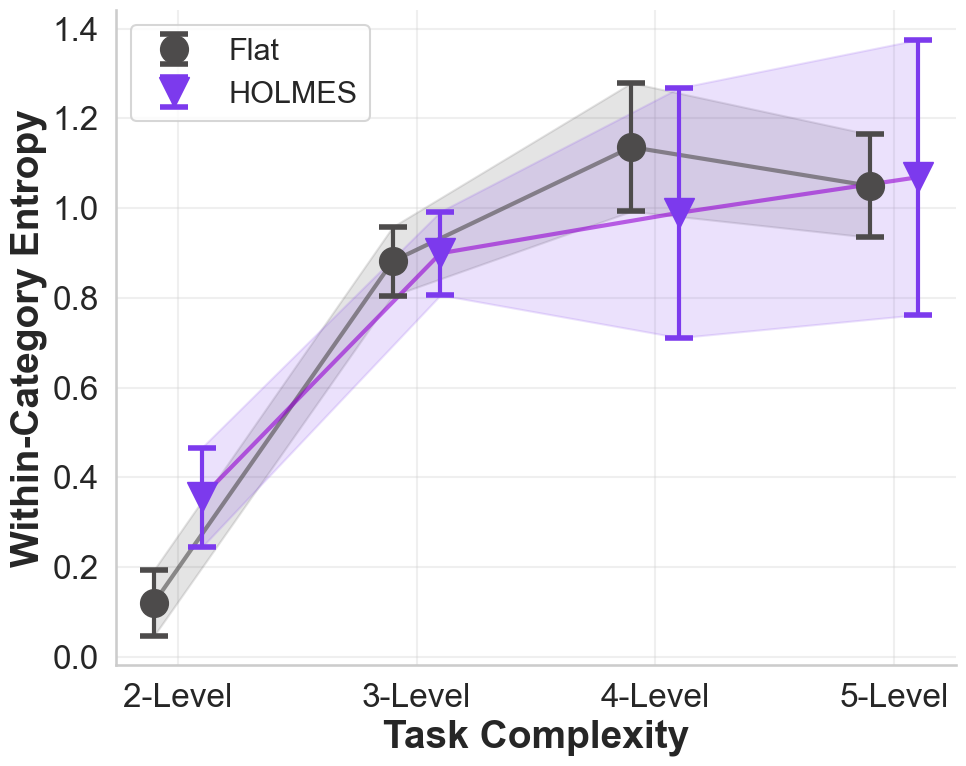


ENTROPY SCALING SUMMARY

2-Level Task:
  Flat:  0.121 ± 0.073 (95% CI)
  Hier:  0.356 ± 0.111 (95% CI)
  Diff:  +0.235 entropy units (Hier - Flat)
  t(4) = 8.140, p = 1.24e-03 (**)

3-Level Task:
  Flat:  0.882 ± 0.077 (95% CI)
  Hier:  0.900 ± 0.093 (95% CI)
  Diff:  +0.018 entropy units (Hier - Flat)
  t(4) = 0.450, p = 6.76e-01 (n.s.)

4-Level Task:
  Flat:  1.136 ± 0.143 (95% CI)
  Hier:  0.990 ± 0.278 (95% CI)
  Diff:  -0.146 entropy units (Hier - Flat)
  t(4) = -1.697, p = 1.65e-01 (n.s.)

5-Level Task:
  Flat:  1.050 ± 0.115 (95% CI)
  Hier:  1.069 ± 0.306 (95% CI)
  Diff:  +0.019 entropy units (Hier - Flat)
  t(4) = 0.163, p = 8.78e-01 (n.s.)


Statistics for '2-Level: Representational Redundancy':
  Flat:  0.12 ± 0.07 (95% CI)
  Hier:  0.36 ± 0.11 (95% CI)
  Diff:  +0.23
  t(4) = 8.140, p = 1.24e-03


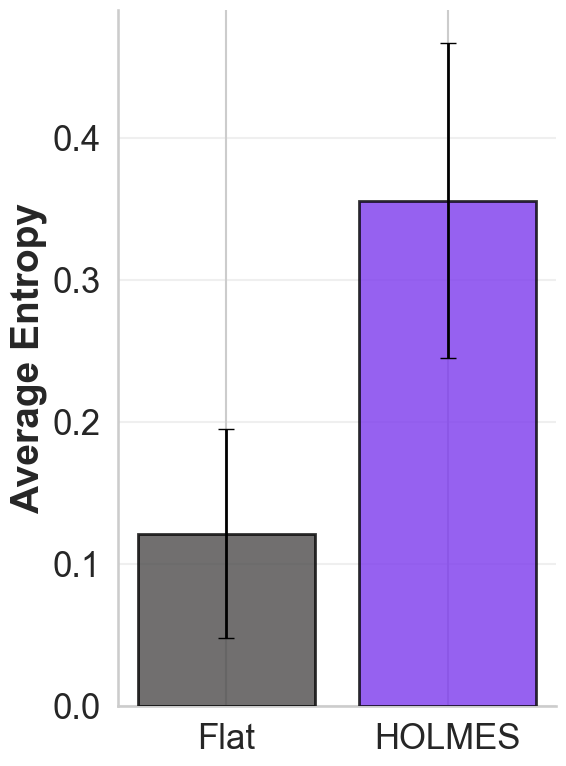


Statistics for '3-Level: Representational Redundancy':
  Flat:  0.88 ± 0.08 (95% CI)
  Hier:  0.90 ± 0.09 (95% CI)
  Diff:  +0.02
  t(4) = 0.450, p = 6.76e-01


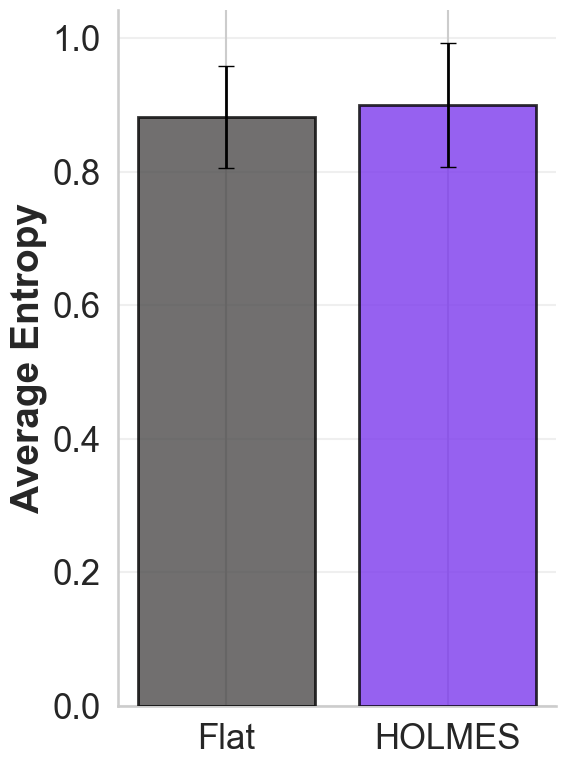

In [157]:

def plot_entropy_comparison(all_results_df, 
                           show_points=True, use_ci=True, show_ci_shade=False, ci_alpha=0.15, show_stats= False):
    """
    Bar chart comparing entropy with individual points.
    
    Args:
        all_results_df: DataFrame with results
        save_path: Path to save figure
        show_points: If True, show individual data points on bars
        use_ci: If True, use 95% CI; if False, use SEM
        show_ci_shade: If True, add shaded CI regions behind bars
        ci_alpha: Transparency of CI shading (default: 0.15)
    """
    import os
    os.makedirs('plots', exist_ok=True)
    
    COLOR_FLAT = "#4D4B4B"
    COLOR_HIER = '#7C3AED'
    
    level_names = {2: 'species', 3: 'prep', 4: 'storage', 5: 'season'}
    
    # Create separate bar chart for each complexity level
    for n_levels in range(2, 4):  # Only 2 and 3 level
        df_n = all_results_df[all_results_df['n_levels'] == n_levels]
        top_name = level_names.get(n_levels)
        
        # Check for new naming with level prefix
        flat_col = f'{top_name}_flat_avg_entropy' if top_name and f'{top_name}_flat_avg_entropy' in df_n.columns else 'flat_avg_entropy'
        hier_col = f'{top_name}_hier_avg_entropy' if top_name and f'{top_name}_hier_avg_entropy' in df_n.columns else 'hier_avg_entropy'
        
        if flat_col in df_n.columns and hier_col in df_n.columns:
            has_flat = df_n[flat_col].notna()
            has_hier = df_n[hier_col].notna()
            valid_seeds = has_flat & has_hier
            
            if valid_seeds.sum() > 0:
                flat_vals = df_n.loc[valid_seeds, flat_col].values
                hier_vals = df_n.loc[valid_seeds, hier_col].values
                
                # Use the helper function for consistent styling
                create_bar_plot(
                    data_flat=flat_vals,
                    data_hier=hier_vals,
                    title=f'{n_levels}-Level: Representational Redundancy',
                    ylabel='Average Entropy',
                    optimal_line=None,  # Lower is better
                    color_flat=COLOR_FLAT,
                    color_hier=COLOR_HIER,
                    show_points=show_points,
                    use_ci=use_ci,
                    show_stats = show_stats
                )

def plot_entropy_scaling(all_results_df, 
                        show_points=True, show_ci=True, use_ci=True, ci_alpha=0.15):
    """
    Entropy across task complexities with confidence intervals (line plot version).
    
    Args:
        all_results_df: DataFrame with results
        save_path: Path to save figure
        show_points: If True, show individual data points with jitter
        show_ci: If True, show shaded confidence interval regions
        use_ci: If True, use 95% CI for error bars; if False, use SEM
        ci_alpha: Transparency of CI shading (default: 0.15)
    """
    import os
    os.makedirs('plots', exist_ok=True)
    
    sns.set_style("whitegrid")
    sns.set_context("talk")
    
    COLOR_FLAT = "#4D4B4B"
    COLOR_HIER = '#7C3AED'
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    level_names = {2: 'species', 3: 'prep', 4: 'storage', 5: 'season'}
    
    levels = []
    flat_all_points = []
    hier_all_points = []
    flat_means = []
    hier_means = []
    flat_errs = []
    hier_errs = []
    flat_ci_lower = []
    flat_ci_upper = []
    hier_ci_lower = []
    hier_ci_upper = []
    
    for n_levels in range(2, 6):
        df_n = all_results_df[all_results_df['n_levels'] == n_levels]
        top_name = level_names.get(n_levels)
        
        if len(df_n) == 0:
            continue
        
        # Check for new naming with level prefix
        flat_col = f'{top_name}_flat_avg_entropy' if top_name and f'{top_name}_flat_avg_entropy' in df_n.columns else 'flat_avg_entropy'
        hier_col = f'{top_name}_hier_avg_entropy' if top_name and f'{top_name}_hier_avg_entropy' in df_n.columns else 'hier_avg_entropy'
        
        if flat_col in df_n.columns and hier_col in df_n.columns:
            # Get seeds with both values
            has_flat = df_n[flat_col].notna()
            has_hier = df_n[hier_col].notna()
            valid_seeds = has_flat & has_hier
            
            if valid_seeds.sum() > 0:
                flat_vals = df_n.loc[valid_seeds, flat_col].values
                hier_vals = df_n.loc[valid_seeds, hier_col].values
                
                # Compute statistics
                flat_mean = np.mean(flat_vals)
                hier_mean = np.mean(hier_vals)
                
                flat_sem = stats.sem(flat_vals)
                hier_sem = stats.sem(hier_vals)
                
                if use_ci:
                    # 95% CI = 1.96 * SEM
                    flat_err = 1.96 * flat_sem
                    hier_err = 1.96 * hier_sem
                else:
                    # Just SEM
                    flat_err = flat_sem
                    hier_err = hier_sem
                
                levels.append(n_levels)
                flat_all_points.append(flat_vals)
                hier_all_points.append(hier_vals)
                flat_means.append(flat_mean)
                hier_means.append(hier_mean)
                flat_errs.append(flat_err)
                hier_errs.append(hier_err)
                
                # Store CI bounds for shading
                flat_ci_lower.append(flat_mean - flat_err)
                flat_ci_upper.append(flat_mean + flat_err)
                hier_ci_lower.append(hier_mean - hier_err)
                hier_ci_upper.append(hier_mean + hier_err)
    
    if len(levels) == 0:
        print("No data to plot")
        return
    
    # Convert to arrays for easier plotting
    levels = np.array(levels)
    flat_means = np.array(flat_means)
    hier_means = np.array(hier_means)
    flat_errs = np.array(flat_errs)
    hier_errs = np.array(hier_errs)
    flat_ci_lower = np.array(flat_ci_lower)
    flat_ci_upper = np.array(flat_ci_upper)
    hier_ci_lower = np.array(hier_ci_lower)
    hier_ci_upper = np.array(hier_ci_upper)
    
    # X positions for flat and hierarchical (slightly offset)
    flat_x_positions = levels - 0.1
    hier_x_positions = levels + 0.1
    
    # Plot shaded confidence intervals FIRST (lowest z-order)
    if show_ci:
        ax.fill_between(flat_x_positions, flat_ci_lower, flat_ci_upper,
                        color=COLOR_FLAT, alpha=ci_alpha, 
                        label='_nolegend_', zorder=1)
        ax.fill_between(hier_x_positions, hier_ci_lower, hier_ci_upper,
                        color=COLOR_HIER, alpha=ci_alpha,
                        label='_nolegend_', zorder=2)
    
    # Plot individual points if enabled
    if show_points:
        np.random.seed(42)
        jitter_amount = 0.08
        
        for i, level in enumerate(levels):
            # Flat points
            x_flat = np.random.normal(level - 0.1, jitter_amount, len(flat_all_points[i]))
            ax.scatter(x_flat, flat_all_points[i], 
                      color=COLOR_FLAT, s=60, alpha=0.3, 
                      edgecolors='none', zorder=5)
            
            # Hierarchical points
            x_hier = np.random.normal(level + 0.1, jitter_amount, len(hier_all_points[i]))
            ax.scatter(x_hier, hier_all_points[i], 
                      color=COLOR_HIER, s=60, alpha=0.3, 
                      edgecolors='none', zorder=6)
    
    # Plot connecting lines between means
    ax.plot(flat_x_positions, flat_means, '-', 
           color=COLOR_FLAT, linewidth=3, alpha=0.6, zorder=7)
    ax.plot(hier_x_positions, hier_means, '-', 
           color='darkviolet', linewidth=3, alpha=0.6, zorder=8)
    
    # Plot means with error bars
    error_label = '95% CI' if use_ci else 'SEM'
    
    ax.errorbar(flat_x_positions, flat_means, 
               yerr=flat_errs,
               fmt='o', markersize=20, capsize=10, capthick=4,
               color=COLOR_FLAT, linewidth=4, elinewidth=3,
               label='Flat', zorder=10)
    
    ax.errorbar(hier_x_positions, hier_means, 
               yerr=hier_errs,
               fmt='v', markersize=21, capsize=10, capthick=4,
               color=COLOR_HIER, linewidth=4, elinewidth=3,
               label='HOLMES', zorder=11)
    
    ax.set_xlabel('Task Complexity', fontsize=28, fontweight='bold')
    ax.set_ylabel('Within-Category Entropy', fontsize=28, fontweight='bold')
    ax.set_xticks(levels)
    ax.set_xticklabels([f'{int(l)}-Level' for l in levels], fontsize=24)
    ax.tick_params(axis='y', labelsize=24)
    
    # Legend
    legend = ax.legend(fontsize=22, frameon=True, loc='upper left')
    
    # # Add note about error bars if showing CI
    # if show_ci:
    #     ci_label_text = f'Shaded regions: {error_label}'
    #     ax.text(0.02, 0.98, ci_label_text,
    #             transform=ax.transAxes, fontsize=14,
    #             verticalalignment='top', horizontalalignment='left',
    #             style='italic',
    #             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    ax.grid(alpha=0.3)
    
    sns.despine()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*80)
    print("ENTROPY SCALING SUMMARY")
    print("="*80)
    error_type = "95% CI" if use_ci else "SEM"
    
    for i, n in enumerate(levels):
        print(f"\n{int(n)}-Level Task:")
        print(f"  Flat:  {flat_means[i]:.3f} ± {flat_errs[i]:.3f} ({error_type})")
        print(f"  Hier:  {hier_means[i]:.3f} ± {hier_errs[i]:.3f} ({error_type})")
        print(f"  Diff:  {hier_means[i] - flat_means[i]:+.3f} entropy units (Hier - Flat)")
        
        if len(flat_all_points[i]) > 1 and len(hier_all_points[i]) > 1:
            # Test if difference is significant
            t, p = stats.ttest_rel(hier_all_points[i], flat_all_points[i])
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
            print(f"  t({len(flat_all_points[i])-1}) = {t:.3f}, p = {p:.2e} ({sig})")
    
    print("="*80 + "\n")


# Use it
plot_entropy_scaling(all_results_df, 
                     show_points=False, show_ci=True, use_ci=True, ci_alpha=0.15)

plot_entropy_comparison(all_results_df, use_ci=True, show_points = False, show_stats = False)

## figure 3

In [158]:
# ====================================================================================
# PLOT 3: TRANSFER ACCURACY SCALING
# ====================================================================================

def plot_transfer_accuracy(all_results_df, show_points=True, use_ci=True):
    """
    Bar chart of transfer accuracy for flat vs hierarchical model,
    one plot per task complexity level.
    
    Args:
        all_results_df: DataFrame with results
        show_points: If True, show individual data points
        use_ci: If True, use 95% CI; if False, use SEM
    """
    COLOR_FLAT = "#4D4B4B"
    COLOR_HIER = '#7C3AED'

    level_names = {2: 'species', 3: 'prep', 4: 'storage', 5: 'season'}

    for n_levels in range(2, 6):
        df_n     = all_results_df[all_results_df['n_levels'] == n_levels]
        top_name = level_names.get(n_levels)
        hier_col = f'{top_name}_hier_recall'
        flat_col = f'{top_name}_flat_recall'

        if hier_col not in df_n.columns:
            continue

        flat_vals = df_n[flat_col].dropna().values * 100
        hier_vals = df_n[hier_col].dropna().values * 100

        if len(flat_vals) == 0 or len(hier_vals) == 0:
            continue

        create_bar_plot(
            data_flat=flat_vals,
            data_hier=hier_vals,
            title=f'{n_levels}-Level Task: Transfer Accuracy',
            ylabel='Recall Accuracy (%)',
            optimal_line=50,
            line_label='Chance Level',
            color_flat=COLOR_FLAT,
            color_hier=COLOR_HIER,
            show_points=show_points,
            use_ci=use_ci
        )
        plt.show()


def plot_transfer_scaling(all_results_df, save_path='plots/transfer_scaling.png', 
                          show_points=True, show_ci=True, use_ci=True, ci_alpha=0.15):
    """
    Transfer accuracy across task complexities with confidence intervals.
    
    Args:
        all_results_df: DataFrame with results
        save_path: Path to save figure
        show_points: If True, show individual data points
        show_ci: If True, show shaded confidence interval regions
        use_ci: If True, use 95% CI; if False, use SEM
        ci_alpha: Transparency of CI shading (default: 0.15)
    """
    sns.set_style("whitegrid")
    sns.set_context("talk")

    level_names = {2: 'species', 3: 'prep', 4: 'storage', 5: 'season'}
    COLOR_FLAT = "#4D4B4B"
    COLOR_HIER = '#7C3AED'

    fig, ax = plt.subplots(figsize=(10, 8))

    levels = []
    flat_all_points, hier_all_points = [], []
    flat_means, hier_means = [], []
    flat_errs, hier_errs = [], []
    flat_ci_lower, flat_ci_upper = [], []
    hier_ci_lower, hier_ci_upper = [], []

    for n_levels in range(2, 6):
        df_n = all_results_df[all_results_df['n_levels'] == n_levels]
        top_name = level_names.get(n_levels)
        hier_col = f'{top_name}_hier_recall'
        flat_col = f'{top_name}_flat_recall'
        
        if hier_col not in df_n.columns and f'{top_name}_hier_transfer' in df_n.columns:
            hier_col = f'{top_name}_hier_transfer'
            flat_col = f'{top_name}_flat_transfer'
        
        if hier_col not in df_n.columns:
            continue

        hier_vals = df_n[hier_col].dropna().values * 100
        flat_vals = df_n[flat_col].dropna().values * 100
        
        if len(hier_vals) == 0:
            continue

        # Compute statistics
        flat_mean = np.mean(flat_vals)
        hier_mean = np.mean(hier_vals)
        flat_sem = stats.sem(flat_vals)
        hier_sem = stats.sem(hier_vals)
        
        if use_ci:
            flat_err = 1.96 * flat_sem
            hier_err = 1.96 * hier_sem
        else:
            flat_err = flat_sem
            hier_err = hier_sem

        levels.append(n_levels)
        flat_all_points.append(flat_vals)
        hier_all_points.append(hier_vals)
        flat_means.append(flat_mean)
        hier_means.append(hier_mean)
        flat_errs.append(flat_err)
        hier_errs.append(hier_err)
        
        # Store CI bounds for shading
        flat_ci_lower.append(flat_mean - flat_err)
        flat_ci_upper.append(flat_mean + flat_err)
        hier_ci_lower.append(hier_mean - hier_err)
        hier_ci_upper.append(hier_mean + hier_err)

    if len(levels) == 0:
        print("No data to plot")
        return
    
    # Convert to arrays
    levels = np.array(levels)
    flat_means = np.array(flat_means)
    hier_means = np.array(hier_means)
    flat_errs = np.array(flat_errs)
    hier_errs = np.array(hier_errs)
    flat_ci_lower = np.array(flat_ci_lower)
    flat_ci_upper = np.array(flat_ci_upper)
    hier_ci_lower = np.array(hier_ci_lower)
    hier_ci_upper = np.array(hier_ci_upper)
    
    # X positions (offset for flat and hierarchical)
    flat_x = levels - 0.1
    hier_x = levels + 0.1

    # Plot shaded confidence intervals FIRST (lowest z-order)
    if show_ci:
        ax.fill_between(flat_x, flat_ci_lower, flat_ci_upper,
                        color=COLOR_FLAT, alpha=ci_alpha, 
                        label='_nolegend_', zorder=1)
        ax.fill_between(hier_x, hier_ci_lower, hier_ci_upper,
                        color=COLOR_HIER, alpha=ci_alpha,
                        label='_nolegend_', zorder=2)

    # Plot individual points if enabled
    if show_points:
        rng = np.random.default_rng(42)
        for i, level in enumerate(levels):
            ax.scatter(rng.normal(level - 0.1, 0.08, len(flat_all_points[i])),
                       flat_all_points[i], color=COLOR_FLAT, s=60, alpha=0.3,
                       edgecolors='none', zorder=5)
            ax.scatter(rng.normal(level + 0.1, 0.08, len(hier_all_points[i])),
                       hier_all_points[i], color=COLOR_HIER, s=60, alpha=0.3,
                       edgecolors='none', zorder=6)

    # Plot connecting lines between means
    ax.plot(flat_x, flat_means, '-', color=COLOR_FLAT, linewidth=3, alpha=0.6, zorder=7)
    ax.plot(hier_x, hier_means, '-', color=COLOR_HIER, linewidth=3, alpha=0.6, zorder=8)

    # Plot means with error bars
    ax.errorbar(flat_x, flat_means, yerr=flat_errs,
                fmt='o', markersize=20, capsize=10, capthick=4,
                color=COLOR_FLAT, linewidth=4, elinewidth=3, label='Flat', zorder=10)
    ax.errorbar(hier_x, hier_means, yerr=hier_errs,
                fmt='v', markersize=21, capsize=10, capthick=4,
                color=COLOR_HIER, linewidth=4, elinewidth=3, label='HOLMES', zorder=11)

    ax.set_xlabel('Task Complexity', fontsize=28, fontweight='bold')
    ax.set_ylabel('Transfer Recall Accuracy (%)', fontsize=28, fontweight='bold')
    ax.set_xticks(levels)
    ax.set_xticklabels([f'{int(l)}-Level' for l in levels], fontsize=24)
    ax.tick_params(axis='y', labelsize=24)
    ax.legend(fontsize=22, frameon=True, loc='best')
    ax.grid(alpha=0.3)
    ax.set_ylim(20, 105)
    
    # # Add note about error bars
    # if show_ci:
    #     error_type = '95% CI' if use_ci else 'SEM'
    #     ax.text(0.02, 0.98, f'Shaded regions: {error_type}',
    #             transform=ax.transAxes, fontsize=14,
    #             verticalalignment='top', style='italic',
    #             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    sns.despine()
    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    print(f"saved transfer scaling plot to {save_path}")
    plt.show()
    
    # Print statistics
    print("\n" + "="*80)
    print("TRANSFER ACCURACY STATISTICS")
    print("="*80)
    error_type = "95% CI" if use_ci else "SEM"
    
    for i, n in enumerate(levels):
        print(f"\n{int(n)}-Level Task:")
        print(f"  Flat:  {flat_means[i]:.1f}% ± {flat_errs[i]:.1f}% ({error_type})")
        print(f"  Hier:  {hier_means[i]:.1f}% ± {hier_errs[i]:.1f}% ({error_type})")
        print(f"  Diff:  {hier_means[i] - flat_means[i]:+.1f}% (Hier - Flat)")
        
        if len(flat_all_points[i]) > 1 and len(hier_all_points[i]) > 1:
            t, p = stats.ttest_rel(hier_all_points[i], flat_all_points[i])
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
            print(f"  t({len(flat_all_points[i])-1}) = {t:.3f}, p = {p:.2e} ({sig})")
    
    print("="*80 + "\n")


def plot_hierarchical_advantage(all_results_df, save_path='plots/hier_advantage.png',
                                 metric='transfer', show_points=True, 
                                 show_ci=True, use_ci=True, ci_alpha=0.15):
    """
    Hierarchical advantage (hier - flat) over task complexity with confidence intervals.

    Args:
        all_results_df: DataFrame with results
        save_path: Path to save figure
        metric: 'transfer' or 'outcome' — which advantage column to plot
        show_points: If True, show per-seed advantage points
        show_ci: If True, show shaded confidence interval regions
        use_ci: If True, use 95% CI; if False, use SEM
        ci_alpha: Transparency of CI shading (default: 0.15)
    """
    import os
    os.makedirs('plots', exist_ok=True)

    sns.set_style("whitegrid")
    sns.set_context("talk")

    COLOR_ADV  = "#00AB6F"
    COLOR_ZERO = '#EF4444'
    level_names = {2: 'species', 3: 'prep', 4: 'storage', 5: 'season'}

    fig, ax = plt.subplots(figsize=(10, 8))

    levels = []
    adv_means = []
    adv_errs = []
    adv_all = []
    adv_ci_lower = []
    adv_ci_upper = []

    for n_levels in range(2, 6):
        df_n = all_results_df[all_results_df['n_levels'] == n_levels]
        top_name = level_names.get(n_levels)

        if metric == 'transfer':
            adv_col = f'{top_name}_transfer_advantages'
            # Fallback: compute from raw columns
            if adv_col not in df_n.columns:
                hier_col = f'{top_name}_hier_recall'
                flat_col = f'{top_name}_flat_recall'
                if hier_col in df_n.columns:
                    adv_vals = (df_n[hier_col] - df_n[flat_col]).dropna().values * 100
                else:
                    continue
            else:
                adv_vals = df_n[adv_col].dropna().values * 100
        else:  # outcome
            adv_col = 'outcome_advantage'
            if adv_col not in df_n.columns:
                continue
            adv_vals = df_n[adv_col].dropna().values * 100

        if len(adv_vals) == 0:
            continue

        # Compute statistics
        adv_mean = np.mean(adv_vals)
        adv_sem = stats.sem(adv_vals)
        
        if use_ci:
            adv_err = 1.96 * adv_sem
        else:
            adv_err = adv_sem

        levels.append(n_levels)
        adv_all.append(adv_vals)
        adv_means.append(adv_mean)
        adv_errs.append(adv_err)
        adv_ci_lower.append(adv_mean - adv_err)
        adv_ci_upper.append(adv_mean + adv_err)

    if len(levels) == 0:
        print("No data to plot")
        return
    
    # Convert to arrays
    levels = np.array(levels)
    adv_means = np.array(adv_means)
    adv_errs = np.array(adv_errs)
    adv_ci_lower = np.array(adv_ci_lower)
    adv_ci_upper = np.array(adv_ci_upper)

    # Zero reference line
    ax.axhline(0, color=COLOR_ZERO, linestyle='--', linewidth=3,
               alpha=0.7, zorder=1, label='No advantage')

    # # Shade above/below zero (background)
    # for i in range(len(levels) - 1):
    #     xs = [levels[i], levels[i+1]]
    #     ys = [adv_means[i], adv_means[i+1]]
    #     color = COLOR_ADV if np.mean(ys) >= 0 else COLOR_ZERO
    #     ax.fill_between(xs, 0, ys, alpha=0.12, color=color, zorder=2)

    # Plot shaded confidence intervals
    if show_ci:
        ax.fill_between(levels, adv_ci_lower, adv_ci_upper,
                        color=COLOR_ADV, alpha=ci_alpha,
                        label='_nolegend_', zorder=3)

    # Plot individual points if enabled
    if show_points:
        rng = np.random.default_rng(42)
        for i, level in enumerate(levels):
            ax.scatter(rng.normal(level, 0.08, len(adv_all[i])),
                       adv_all[i], color=COLOR_ADV, s=60, alpha=0.3,
                       edgecolors='none', zorder=5)

    # Plot connecting line and error bars
    ax.plot(levels, adv_means, '-', color=COLOR_ADV, linewidth=3, alpha=0.6, zorder=7)
    ax.errorbar(levels, adv_means, yerr=adv_errs,
                fmt='o', markersize=18, capsize=10, capthick=4,
                color=COLOR_ADV, linewidth=4, elinewidth=3,
                label='Hier − Flat', zorder=10)

    ylabel = 'Transfer Recall Advantage (%)' if metric == 'transfer' else 'Outcome Prediction Advantage (%)'
    ax.set_xlabel('Task Complexity', fontsize=28, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=28, fontweight='bold')
    ax.set_xticks(levels)
    ax.set_xticklabels([f'{int(l)}-Level' for l in levels], fontsize=24)
    ax.tick_params(axis='y', labelsize=24)
    ax.set_ylim(-10, 35)
    ax.grid(alpha=0.3)
    
    # # Add note about error bars
    # if show_ci:
    #     error_type = '95% CI' if use_ci else 'SEM'
    #     ax.text(0.02, 0.98, f'Shaded region: {error_type}',
    #             transform=ax.transAxes, fontsize=14,
    #             verticalalignment='top', style='italic',
    #             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    sns.despine()
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "="*80)
    print(f"HIERARCHICAL ADVANTAGE ({metric.upper()}) STATISTICS")
    print("="*80)
    error_type = "95% CI" if use_ci else "SEM"
    
    for i, n in enumerate(levels):
        print(f"\n{int(n)}-Level Task:")
        print(f"  Advantage: {adv_means[i]:+.1f}% ± {adv_errs[i]:.1f}% ({error_type})")
        
        if len(adv_all[i]) > 1:
            # Test if advantage is significantly different from zero
            t, p = stats.ttest_1samp(adv_all[i], 0)
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
            print(f"  vs. zero: t({len(adv_all[i])-1}) = {t:.3f}, p = {p:.2e} ({sig})")
    
    print("="*80 + "\n")



saved transfer scaling plot to plots/transfer_scaling.png


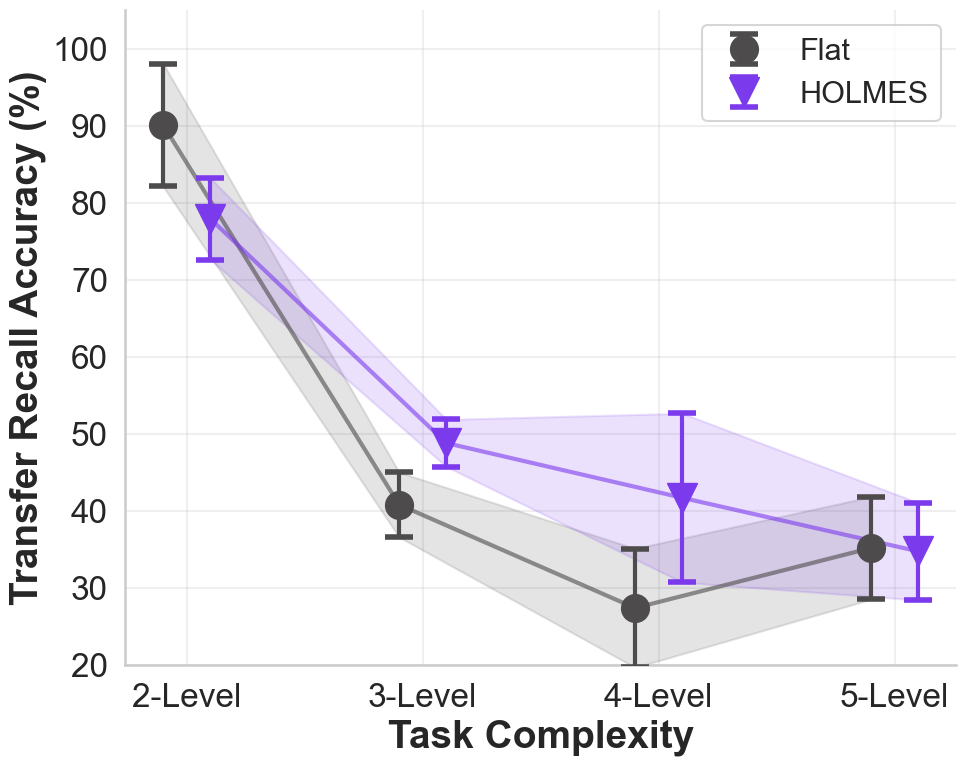


TRANSFER ACCURACY STATISTICS

2-Level Task:
  Flat:  90.1% ± 8.0% (95% CI)
  Hier:  77.9% ± 5.3% (95% CI)
  Diff:  -12.2% (Hier - Flat)
  t(4) = -2.120, p = 1.01e-01 (n.s.)

3-Level Task:
  Flat:  40.8% ± 4.2% (95% CI)
  Hier:  48.8% ± 3.1% (95% CI)
  Diff:  +8.0% (Hier - Flat)
  t(4) = 4.330, p = 1.24e-02 (*)

4-Level Task:
  Flat:  27.4% ± 7.7% (95% CI)
  Hier:  41.7% ± 11.0% (95% CI)
  Diff:  +14.3% (Hier - Flat)
  t(4) = 3.325, p = 2.93e-02 (*)

5-Level Task:
  Flat:  35.2% ± 6.7% (95% CI)
  Hier:  34.8% ± 6.3% (95% CI)
  Diff:  -0.4% (Hier - Flat)
  t(4) = -0.105, p = 9.21e-01 (n.s.)



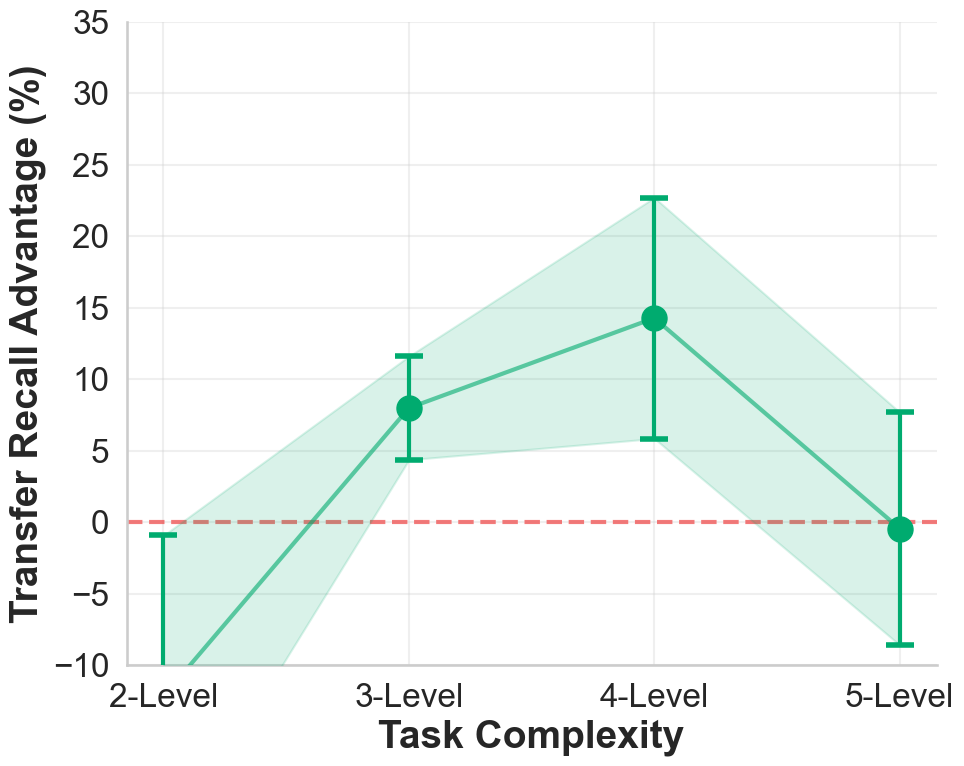


HIERARCHICAL ADVANTAGE (TRANSFER) STATISTICS

2-Level Task:
  Advantage: -12.2% ± 11.2% (95% CI)
  vs. zero: t(4) = -2.120, p = 1.01e-01 (n.s.)

3-Level Task:
  Advantage: +8.0% ± 3.6% (95% CI)
  vs. zero: t(4) = 4.330, p = 1.24e-02 (*)

4-Level Task:
  Advantage: +14.3% ± 8.4% (95% CI)
  vs. zero: t(4) = 3.325, p = 2.93e-02 (*)

5-Level Task:
  Advantage: -0.4% ± 8.1% (95% CI)
  vs. zero: t(4) = -0.105, p = 9.21e-01 (n.s.)



In [159]:

plot_transfer_scaling(all_results_df, show_points=False, show_ci=True, use_ci=True, ci_alpha=0.15)
plot_hierarchical_advantage(all_results_df, metric='transfer', show_points=False, show_ci=True, use_ci=True, ci_alpha=0.15)

In [160]:
def plot_transfer_vs_outcome_scatter(all_results_df, save_path='plots/transfer_vs_outcome_scatter.png',
                                     show_points=True, plot_separately=False):
    """
    Regression lines with confidence intervals for outcome prediction (x) vs transfer (y).
    
    Args:
        all_results_df: DataFrame with results (can be aggregated or raw)
        save_path: Path to save figure (or base path if plot_separately=True)
        show_points: If True, show scatter points
        plot_separately: If True, create separate figure for each complexity level
    """
    import os
    from scipy.stats import t as t_dist
    os.makedirs('plots', exist_ok=True)

    sns.set_style("whitegrid")
    sns.set_context("talk")
    COLOR_FLAT = "#4D4B4B"
    COLOR_HIER = '#7C3AED'

    level_names = {2: 'species', 3: 'prep', 4: 'storage', 5: 'season'}
    
    # Check if we have pre-computed asymptotic accuracy
    has_asymptotic = 'flat_asymptotic_acc' in all_results_df.columns
    
    # Determine column names based on data type
    if has_asymptotic:
        flat_outcome_col = 'flat_asymptotic_acc'
        hier_outcome_col = 'hier_asymptotic_acc'
        print("Using pre-computed asymptotic accuracy for outcome prediction")
    else:
        flat_outcome_col = 'flat_outcome_acc'
        hier_outcome_col = 'hier_outcome_acc'
        print("Using outcome_acc columns")

    complexities = sorted(all_results_df['n_levels'].unique())

    def regression_with_ci(xv, yv, color, ax, label, ci=0.95):
        """Plot regression line with shaded confidence interval."""
        if len(xv) < 3:
            return None
        
        # Check if all x values are identical
        if np.std(xv) < 1e-6:
            print(f" Skipping regression for {label}: all x values identical ({np.mean(xv):.1f}%)")
            return None
        
        m, b, r, p, se = stats.linregress(xv, yv)
        xfit = np.linspace(xv.min(), xv.max(), 200)
        yfit = m * xfit + b

        # Confidence interval on the regression line
        n    = len(xv)
        dof  = n - 2
        t_crit = t_dist.ppf((1 + ci) / 2, dof)
        x_mean = np.mean(xv)
        ss_x   = np.sum((xv - x_mean) ** 2)
        y_pred = m * xv + b
        s_err  = np.sqrt(np.sum((yv - y_pred) ** 2) / dof)
        se_line = s_err * np.sqrt(1/n + (xfit - x_mean)**2 / ss_x)
        ci_band = t_crit * se_line

        ax.fill_between(xfit, yfit - ci_band, yfit + ci_band,
                        color=color, alpha=0.18, zorder=3)
        ax.plot(xfit, yfit, color=color, linewidth=3,
                alpha=0.95, zorder=4, label=label)

        return r, p, m

    if plot_separately:
        # Create separate figure for each complexity level
        for n_levels in complexities:
            df_n  = all_results_df[all_results_df['n_levels'] == n_levels]
            name  = level_names.get(n_levels)
            tcol_h = f'{name}_hier_recall'
            tcol_f = f'{name}_flat_recall'

            if tcol_h not in df_n.columns:
                print(f" Skipping {n_levels}-level: no transfer columns")
                continue

            fig, ax = plt.subplots(figsize=(10, 8))

            # Get outcome and transfer data
            flat_x = df_n[flat_outcome_col].dropna() * 100
            flat_y = df_n[tcol_f].dropna() * 100
            common_f = flat_x.index.intersection(flat_y.index)

            hier_x = df_n[hier_outcome_col].dropna() * 100
            hier_y = df_n[tcol_h].dropna() * 100
            common_h = hier_x.index.intersection(hier_y.index)
            
            if len(common_f) == 0 or len(common_h) == 0:
                print(f"Skipping {n_levels}-level: no valid data")
                plt.close(fig)
                continue

            # Scatter points
            if show_points:
                ax.scatter(flat_x[common_f].values, flat_y[common_f].values, 
                          color=COLOR_FLAT, s=40, alpha=0.4, 
                          edgecolors='white', linewidth=0.5, zorder=2,
                          label='Flat')
                ax.scatter(hier_x[common_h].values, hier_y[common_h].values,
                          color=COLOR_HIER, s=40, alpha=0.4,
                          edgecolors='white', linewidth=0.5, zorder=2,
                          label='HOLMES')

            # Regression lines
            print(f"\n{n_levels}-Level Task:")
            results = []
            for xv, yv, color, label_text in [
                (flat_x[common_f].values, flat_y[common_f].values, COLOR_FLAT, 'Flat'),
                (hier_x[common_h].values, hier_y[common_h].values, COLOR_HIER, 'HOLMES'),
            ]:
                result = regression_with_ci(xv, yv, color, ax, label_text)
                if result:
                    results.append((label_text, result[0], result[1], result[2]))


            # Add statistics text box on the RIGHT
            if results:
                text_lines = []
                for label_text, r, p, slope in results:
                    p_str = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
            #         color_name = 'Flat' if label_text == 'Flat' else 'HOLMES'
            #         text_lines.append(f'{color_name}: r={r:.2f}, {p_str}')
            #         text_lines.append(f'       slope={slope:.3f}')
                
            #     stats_text = '\n'.join(text_lines)
            #     ax.text(0.98, 0.95, stats_text,
            #             transform=ax.transAxes, fontsize=14,
            #             verticalalignment='top', horizontalalignment='right',
            #             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            #             family='monospace')
            else:
                # No regression possible (all x identical)
                ax.text(0.5, 0.5, 'Insufficient variance in outcome accuracy\nfor regression analysis',
                        transform=ax.transAxes, fontsize=16,
                        verticalalignment='center', horizontalalignment='center',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                        style='italic')

            ax.set_xlabel('Outcome Prediction (%)', fontsize=28, fontweight='bold')
            ax.set_ylabel('Transfer Recall Accuracy (%)', fontsize=28, fontweight='bold')
            ax.set_title(f'{n_levels}-Level Task: Transfer vs Outcome Correlation', 
                        fontsize=22, fontweight='bold', pad=15)
            ax.tick_params(labelsize=20)
            

            ax.legend(fontsize=16, frameon=True, loc='upper left')
            
            ax.grid(alpha=0.3)
            sns.despine(ax=ax)

            plt.tight_layout()
            
            # Save with level-specific filename
            plt.show()
            
    else:
        # Original: all levels in one figure
        n_plots = len(complexities)
        fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 6), sharey=False)
        if n_plots == 1:
            axes = [axes]

        for ax, n_levels in zip(axes, complexities):
            df_n  = all_results_df[all_results_df['n_levels'] == n_levels]
            name  = level_names.get(n_levels)
            tcol_h = f'{name}_hier_recall'
            tcol_f = f'{name}_flat_recall'

            if tcol_h not in df_n.columns:
                ax.set_visible(False)
                continue

            flat_x = df_n[flat_outcome_col].dropna() * 100
            flat_y = df_n[tcol_f].dropna() * 100
            common_f = flat_x.index.intersection(flat_y.index)

            hier_x = df_n[hier_outcome_col].dropna() * 100
            hier_y = df_n[tcol_h].dropna() * 100
            common_h = hier_x.index.intersection(hier_y.index)
            
            if len(common_f) == 0 or len(common_h) == 0:
                ax.set_visible(False)
                continue

            # Scatter points
            if show_points:
                ax.scatter(flat_x[common_f].values, flat_y[common_f].values,
                          color=COLOR_FLAT, s=30, alpha=0.4,
                          edgecolors='white', linewidth=0.5, zorder=2)
                ax.scatter(hier_x[common_h].values, hier_y[common_h].values,
                          color=COLOR_HIER, s=30, alpha=0.4,
                          edgecolors='white', linewidth=0.5, zorder=2)

            # Regression lines
            has_regression = False
            for xv, yv, color, label, ypos in [
                (flat_x[common_f].values, flat_y[common_f].values, COLOR_FLAT, 'Flat',          0.95),
                (hier_x[common_h].values, hier_y[common_h].values, COLOR_HIER, 'HOLMES',  0.87),
            ]:
                result = regression_with_ci(xv, yv, color, ax, label)
                if result:
                    has_regression = True
                    r, p, slope = result
                    p_str = f'p<0.001' if p < 0.001 else f'p={p:.3f}'
                #     ax.text(0.95, ypos, f'r={r:.2f}, {p_str}',
                #             transform=ax.transAxes, fontsize=13,
                #             color=color, va='top', ha='right', fontweight='bold')



            ax.set_xlabel('Outcome Prediction (%)', fontsize=22, fontweight='bold')
            ax.set_ylabel('Transfer Recall Accuracy (%)', fontsize=22, fontweight='bold')
            ax.set_title(f'{n_levels}-Level Task', fontsize=24, fontweight='bold')
            ax.tick_params(labelsize=16)
            if n_levels == complexities[0]:
                ax.legend(fontsize=15, frameon=True, loc='upper left')
            ax.grid(alpha=0.3)
            sns.despine(ax=ax)

        plt.suptitle('Transfer vs Outcome Prediction: Correlation Analysis',
                     fontsize=26, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()



Using outcome_acc columns

2-Level Task:


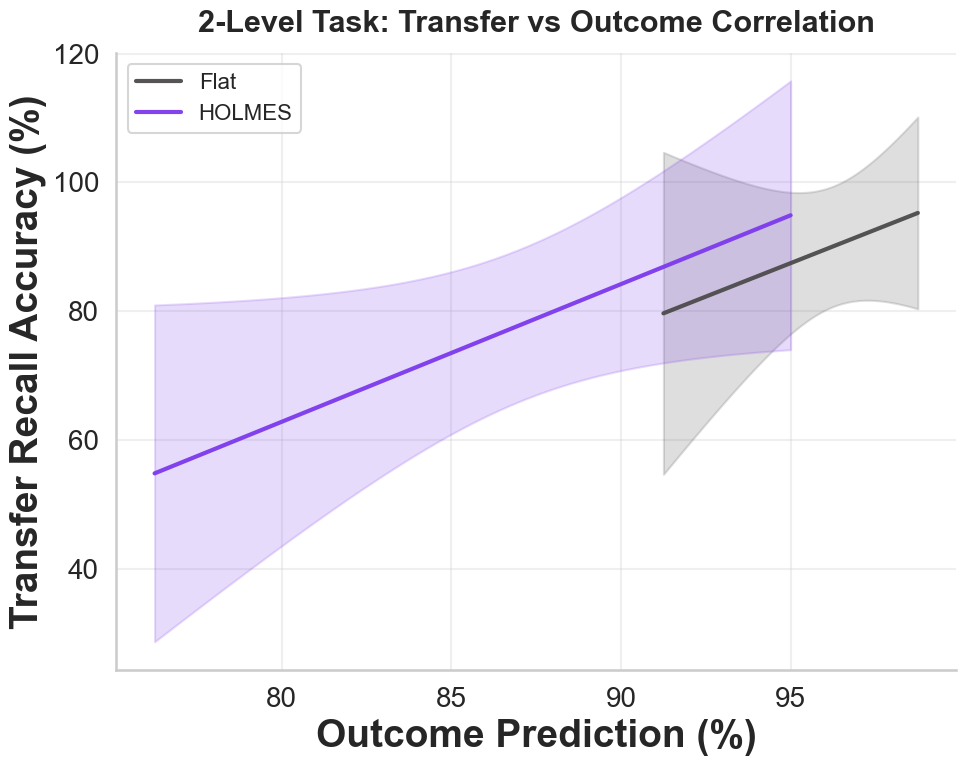


3-Level Task:


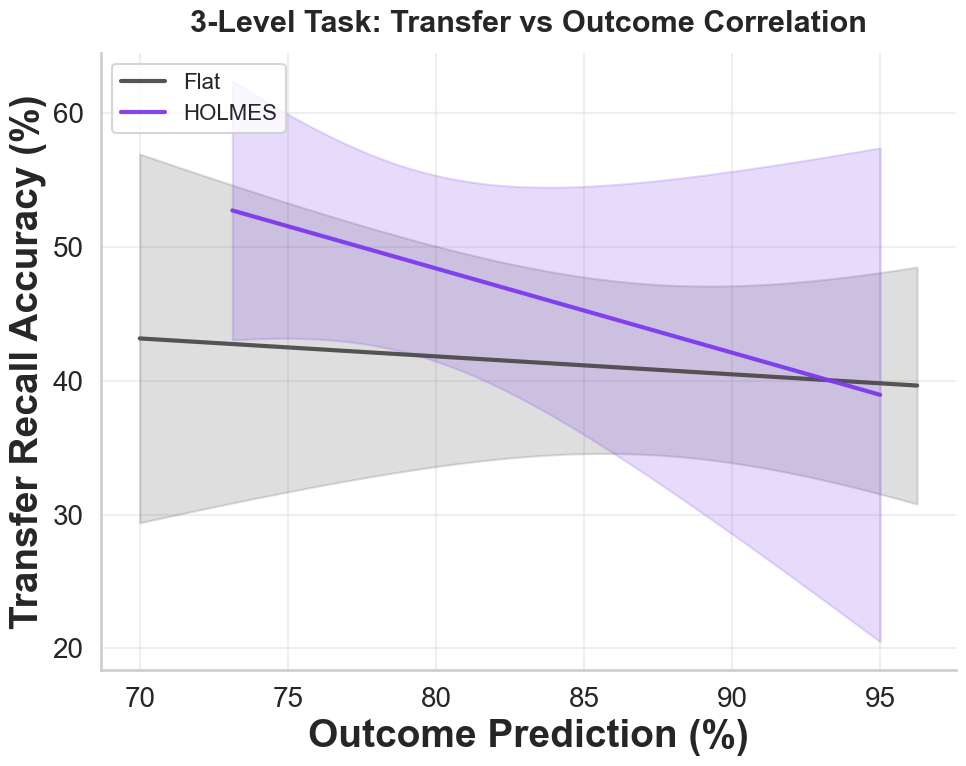


4-Level Task:


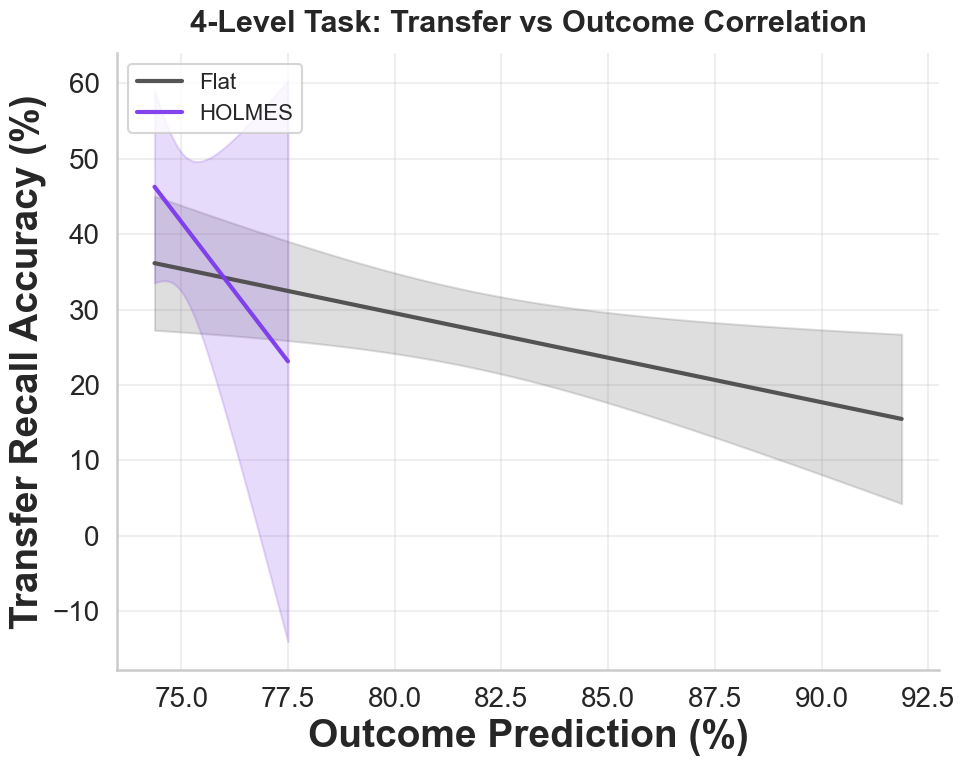


5-Level Task:


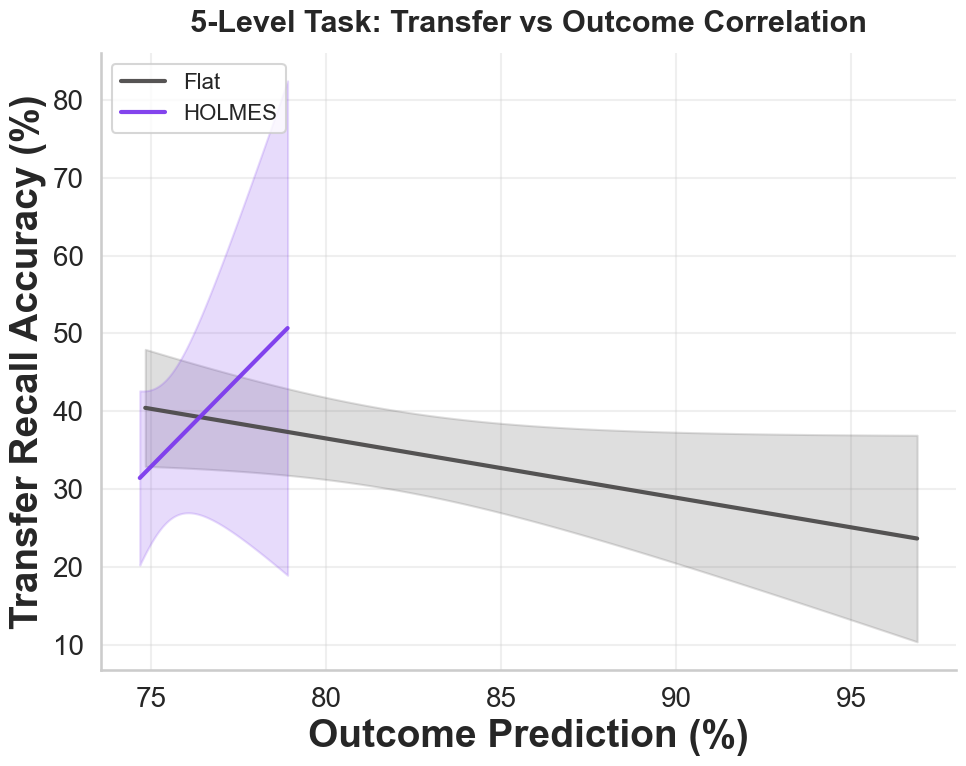

In [161]:

plot_transfer_vs_outcome_scatter(all_results_df1,
                                 plot_separately=True, show_points = False)



/var/folders/7c/qjwf8h0d0l9f486sgfxttzww0000gn/T/ipykernel_97684/1578663452.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmaps[mdl]).copy()


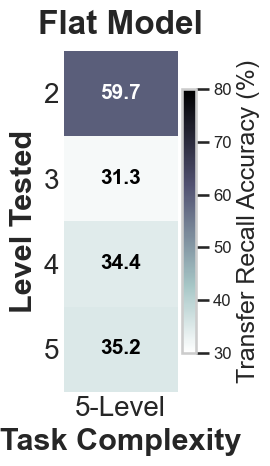

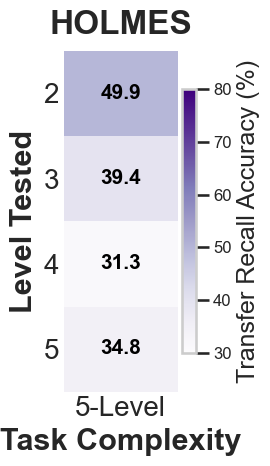

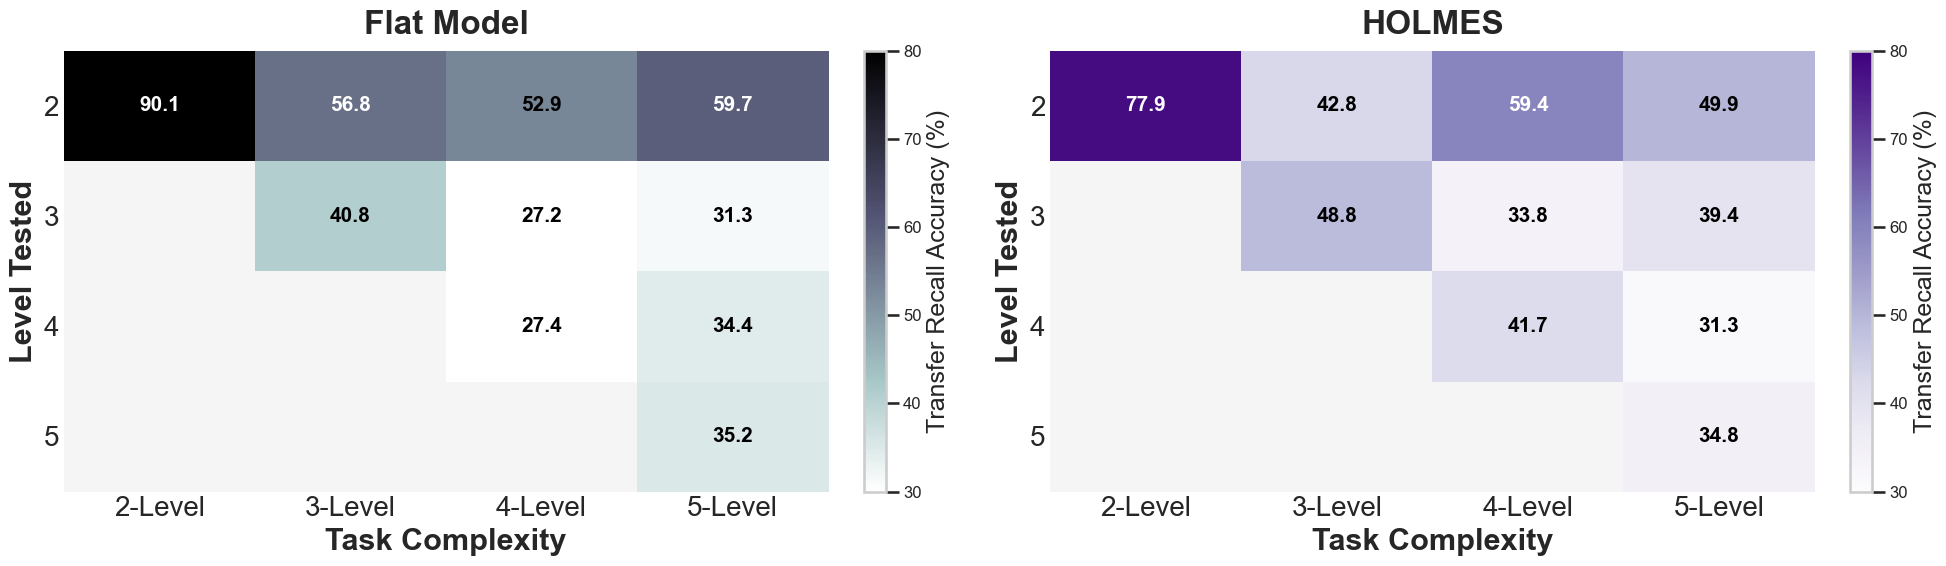

In [162]:

def plot_transfer_accuracy_heatmap(all_results_df, save_path='plots/transfer_heatmap.png',
                                    model='both',
                                    complexities=[5],
                                    tested_levels=[2, 3, 4, 5], fig_size = 3, fig_size2 = 5):

    level_names   = {2: 'species', 3: 'prep', 4: 'storage', 5: 'season'}

    models = ['flat', 'hier'] if model == 'both' else [model]
    titles = {'flat': 'Flat Model', 'hier': 'HOLMES'}
    cmaps  = {'flat': 'bone_r', 'hier': 'Purples'}

    fig, axes = plt.subplots(1, len(models),
                              figsize=(fig_size * len(models), fig_size2),
                              squeeze=False)

    for ax, mdl in zip(axes[0], models):
        matrix = np.full((len(tested_levels), len(complexities)), np.nan)

        for ci, n_levels in enumerate(complexities):
            df_n = all_results_df[all_results_df['n_levels'] == n_levels]
            for ri, test_level in enumerate(tested_levels):
                if test_level > n_levels:
                    continue
                name = level_names[test_level]
                col  = f'{name}_{mdl}_recall'
                if col in df_n.columns:
                    vals = df_n[col].dropna().values * 100
                    if len(vals) > 0:
                        matrix[ri, ci] = np.mean(vals)

        masked   = np.ma.masked_invalid(matrix)
        cmap_obj = plt.cm.get_cmap(cmaps[mdl]).copy()
        cmap_obj.set_bad(color='#f5f5f5')

        im = ax.imshow(masked, aspect='auto', cmap=cmap_obj,
                       vmin=30, vmax=80, origin='upper',
                       interpolation='nearest')

        ax.grid(False)
        ax.grid(False, which='minor')
        ax.tick_params(which='both', length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

        cb = plt.colorbar(im, ax=ax, fraction=0.1, pad=0.04)
        cb.set_label('Transfer Recall Accuracy (%)', fontsize=18)
        cb.ax.tick_params(labelsize=12)

        for ri in range(len(tested_levels)):
            for ci_idx in range(len(complexities)):
                if not np.isnan(matrix[ri, ci_idx]):
                    val = matrix[ri, ci_idx]
                    text_color = 'white' if val >= 55 else 'black'
                    ax.text(ci_idx, ri, f'{val:.1f}',
                            ha='center', va='center', fontsize=15,
                            fontweight='bold', color=text_color)

        ax.set_xticks(range(len(complexities)))
        ax.set_xticklabels([f'{l}-Level' for l in complexities], fontsize=20)
        ax.set_yticks(range(len(tested_levels)))
        ax.set_yticklabels(['2', '3', '4', '5'], fontsize=20)
        ax.set_xlabel('Task Complexity', fontsize=22, fontweight='bold')
        ax.set_ylabel('Level Tested', fontsize=22, fontweight='bold')
        ax.set_title(titles[mdl], fontsize=24, fontweight='bold', pad=12)

    plt.tight_layout()
    plt.show()



plot_transfer_accuracy_heatmap(all_results_df, model='flat')   # or 'flat' / 'hier'
plot_transfer_accuracy_heatmap(all_results_df, model='hier')   # or 'flat' / 'hier'

plot_transfer_accuracy_heatmap(all_results_df, complexities = [2,3,4,5],model='both', fig_size = 10, fig_size2 = 6)   # or 'flat' / 'hier'

Processing 5 valid parameter combinations...


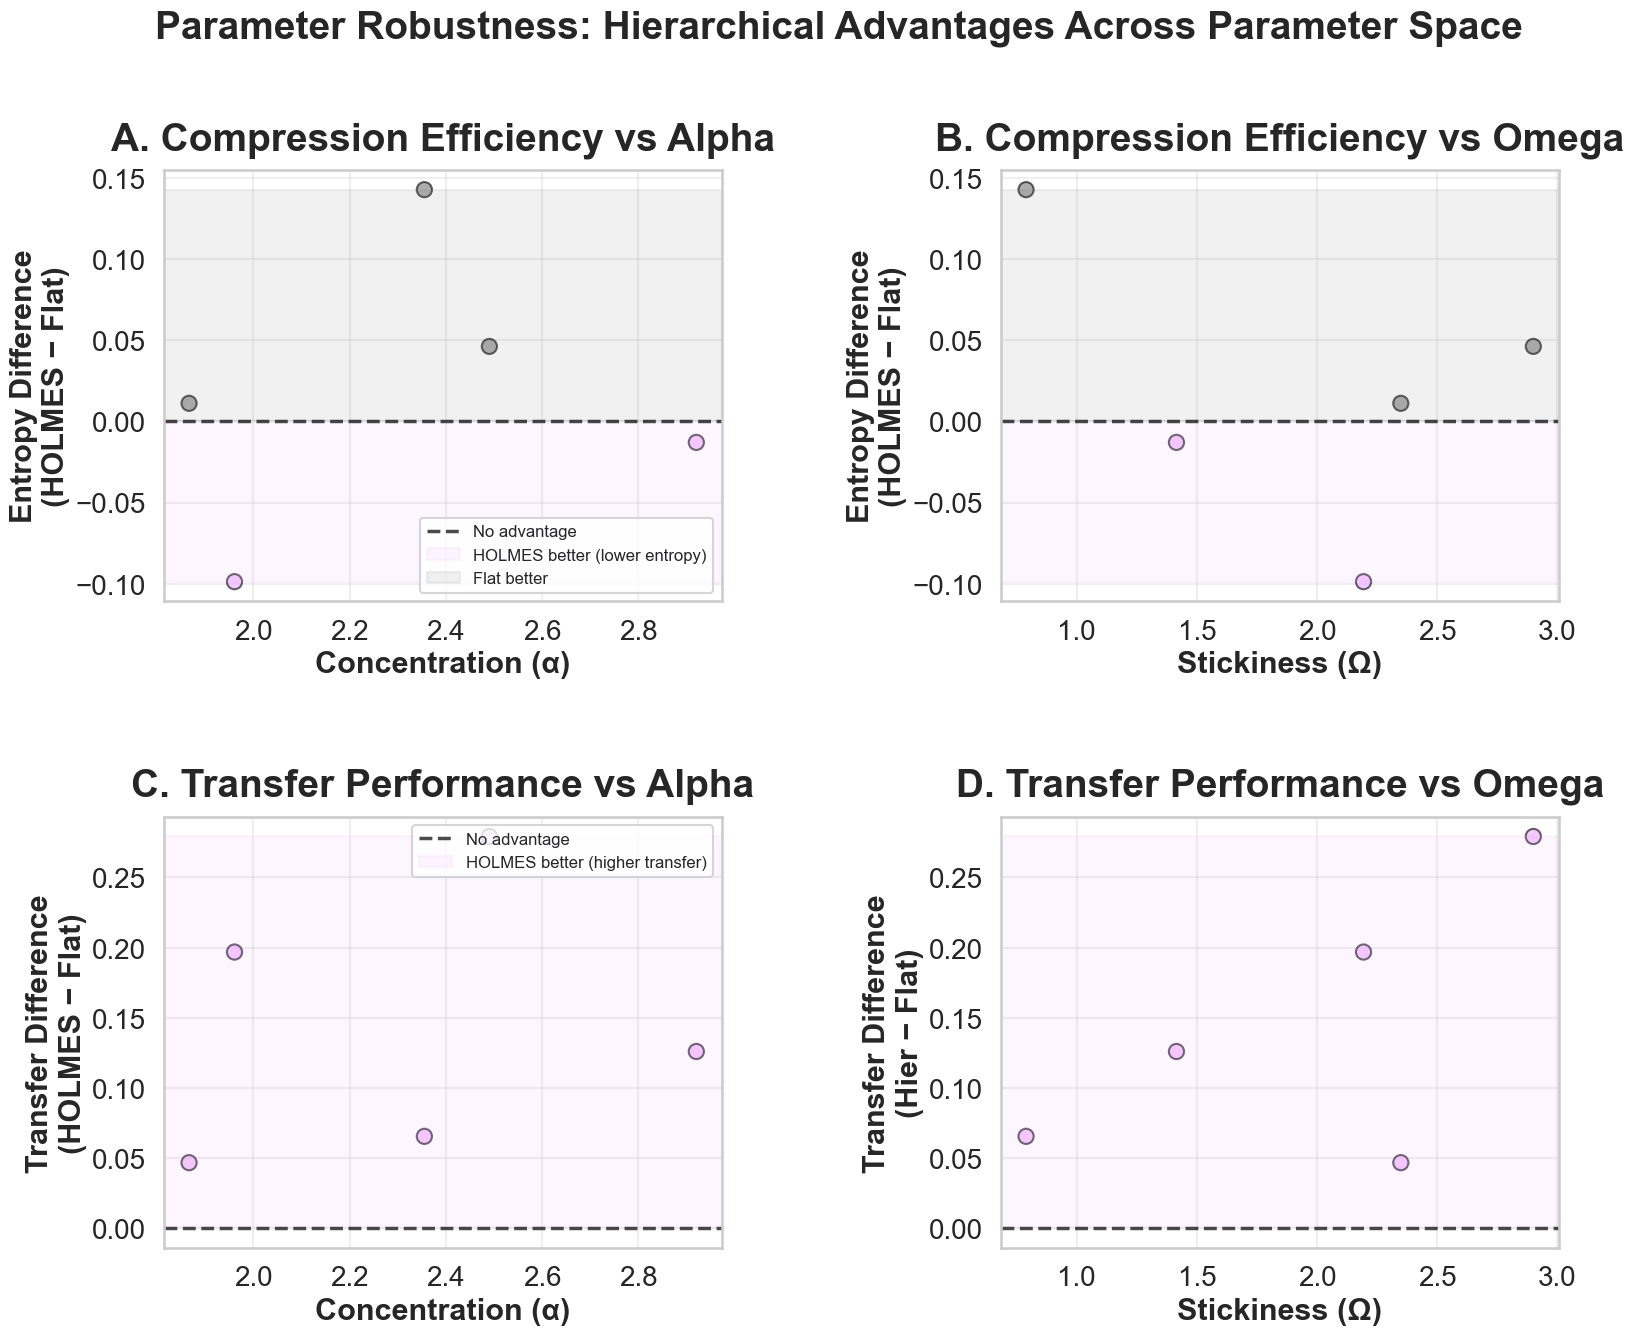

In [163]:
def plot_parameter_robustness_combined(sweep_df):
    """
    Four-panel plot showing robustness of key findings across parameter space.
    
    Shows that hierarchical advantages in compression and transfer hold across
    wide range of alpha and omega parameters.
    
    Args:
        sweep_df: DataFrame from parameter sweep with columns:
            - 'alpha', 'omega': parameter values
            - 'results': nested list of per-seed results
        save_path: Path to save figure
    """
    import os
    os.makedirs('plots', exist_ok=True)
    
    sns.set_style("whitegrid")
    sns.set_context("talk")
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    COLOR_GOOD = "#EDA7FF"  # Green for positive hierarchical advantage
    COLOR_BAD = "#7A7979"   # Red for negative (flat better)
    
    # Extract parameter values and compute advantages
    alphas = []
    omegas = []
    entropy_advantages = []  # hier - flat (negative = hier better, lower entropy)
    transfer_advantages = [] # hier - flat (positive = hier better)
    
    for idx, row in sweep_df.iterrows():
        alphas.append(row['alpha'])
        omegas.append(row['omega'])
        
        # Expand nested results into DataFrame
        results_df = pd.DataFrame(row['results'])
        
        # Compute ENTROPY advantage (use 3-level task)
        # Negative values = hierarchical is better (lower entropy)
        df_3 = results_df[results_df['n_levels'] == 3]
        if len(df_3) > 0 and 'prep_flat_avg_entropy' in df_3.columns and 'prep_hier_avg_entropy' in df_3.columns:
            flat_ent = df_3['prep_flat_avg_entropy'].dropna().mean()
            hier_ent = df_3['prep_hier_avg_entropy'].dropna().mean()
            entropy_adv = hier_ent - flat_ent
        else:
            # Fallback: try 2-level (species)
            df_2 = results_df[results_df['n_levels'] == 2]
            if len(df_2) > 0 and 'species_flat_avg_entropy' in df_2.columns and 'species_hier_avg_entropy' in df_2.columns:
                flat_ent = df_2['species_flat_avg_entropy'].dropna().mean()
                hier_ent = df_2['species_hier_avg_entropy'].dropna().mean()
                entropy_adv = hier_ent - flat_ent
            else:
                entropy_adv = np.nan
        
        entropy_advantages.append(entropy_adv)
        
        # Compute TRANSFER advantage (use 4-level task)
        # Positive values = hierarchical is better
        df_4 = results_df[results_df['n_levels'] == 4]
        if len(df_4) > 0 and 'storage_hier_recall' in df_4.columns and 'storage_flat_recall' in df_4.columns:
            hier_trans = df_4['storage_hier_recall'].dropna().mean()
            flat_trans = df_4['storage_flat_recall'].dropna().mean()
            transfer_adv = hier_trans - flat_trans
        else:
            # Fallback: use the pre-computed transfer_advantage from sweep_df
            transfer_adv = row.get('transfer_advantage', np.nan)
        
        transfer_advantages.append(transfer_adv)
    
    # Convert to numpy arrays
    alphas = np.array(alphas)
    omegas = np.array(omegas)
    entropy_advantages = np.array(entropy_advantages)
    transfer_advantages = np.array(transfer_advantages)
    
    # Remove NaN values
    valid_mask = ~(np.isnan(entropy_advantages) | np.isnan(transfer_advantages))
    
    if not np.any(valid_mask):
        print("ERROR: No valid data found in sweep_df")
        print("Checking first result structure:")
        if len(sweep_df) > 0:
            sample_results = pd.DataFrame(sweep_df.iloc[0]['results'])
            print(f"Available columns in results: {sample_results.columns.tolist()}")
            print(f"Available n_levels: {sample_results['n_levels'].unique()}")
        return
    
    alphas = alphas[valid_mask]
    omegas = omegas[valid_mask]
    entropy_advantages = entropy_advantages[valid_mask]
    transfer_advantages = transfer_advantages[valid_mask]
    
    print(f"Processing {len(alphas)} valid parameter combinations...")
    
    # ========================================================================
    # PANEL A: Entropy Advantage vs Alpha
    # ========================================================================
    ax = axes[0, 0]
    
    # Color by whether hier is better (entropy lower = negative advantage)
    colors_a = [COLOR_GOOD if e < 0 else COLOR_BAD for e in entropy_advantages]
    
    ax.scatter(alphas, entropy_advantages, c=colors_a, alpha=0.6, s=120, 
              edgecolors='black', linewidth=1.5)
    ax.axhline(0, color='black', linestyle='--', linewidth=2.5, alpha=0.7,
              label='No advantage')
    
    # Shade regions
    y_min, y_max = np.min(entropy_advantages), np.max(entropy_advantages)
    ax.axhspan(y_min, 0, alpha=0.1, color=COLOR_GOOD, 
              label='HOLMES better (lower entropy)')
    if y_max > 0:
        ax.axhspan(0, y_max, alpha=0.1, color=COLOR_BAD,
                  label='Flat better')
    
    # Calculate percentage where hier is better
    pct_better = 100 * np.sum(entropy_advantages < 0) / len(entropy_advantages)
    
    # ax.text(0.05, 0.95, f'{pct_better:.0f}% favor hierarchical',
    #        transform=ax.transAxes, fontsize=14, fontweight='bold',
    #        verticalalignment='top', bbox=dict(boxstyle='round', 
    #        facecolor='white', alpha=0.8, edgecolor='black', linewidth=2))
    
    ax.set_xlabel('Concentration (α)', fontsize=22, fontweight='bold')
    ax.set_ylabel('Entropy Difference\n(HOLMES − Flat)', fontsize=22, fontweight='bold')
    ax.set_title('A. Compression Efficiency vs Alpha', fontsize=28, fontweight='bold', pad=15)
    ax.tick_params(axis='both', labelsize=20)
    ax.legend(fontsize=12, loc='lower right', frameon=True)
    ax.grid(alpha=0.3)
    
    # ========================================================================
    # PANEL B: Entropy Advantage vs Omega
    # ========================================================================
    ax = axes[0, 1]
    
    colors_b = [COLOR_GOOD if e < 0 else COLOR_BAD for e in entropy_advantages]
    
    ax.scatter(omegas, entropy_advantages, c=colors_b, alpha=0.6, s=120,
              edgecolors='black', linewidth=1.5)
    ax.axhline(0, color='black', linestyle='--', linewidth=2.5, alpha=0.7)
    
    ax.axhspan(y_min, 0, alpha=0.1, color=COLOR_GOOD)
    if y_max > 0:
        ax.axhspan(0, y_max, alpha=0.1, color=COLOR_BAD)
    
    # ax.text(0.05, 0.95, f'{pct_better:.0f}% favor hierarchical',
    #        transform=ax.transAxes, fontsize=14, fontweight='bold',
    #        verticalalignment='top', bbox=dict(boxstyle='round',
    #        facecolor='white', alpha=0.8, edgecolor='black', linewidth=2))
    
    ax.set_xlabel('Stickiness (Ω)', fontsize=22, fontweight='bold')
    ax.set_ylabel('Entropy Difference\n(HOLMES − Flat)', fontsize=22, fontweight='bold')
    ax.set_title('B. Compression Efficiency vs Omega', fontsize=28, fontweight='bold', pad=15)
    ax.tick_params(axis='both', labelsize=20)
    ax.grid(alpha=0.3)
    
    # ========================================================================
    # PANEL C: Transfer Advantage vs Alpha
    # ========================================================================
    ax = axes[1, 0]
    
    # Color by whether hier is better (transfer higher = positive advantage)
    colors_c = [COLOR_GOOD if t > 0 else COLOR_BAD for t in transfer_advantages]
    
    ax.scatter(alphas, transfer_advantages, c=colors_c, alpha=0.6, s=120,
              edgecolors='black', linewidth=1.5)
    ax.axhline(0, color='black', linestyle='--', linewidth=2.5, alpha=0.7,
              label='No advantage')
    
    t_min, t_max = np.min(transfer_advantages), np.max(transfer_advantages)
    if t_max > 0:
        ax.axhspan(0, t_max, alpha=0.1, color=COLOR_GOOD,
                  label='HOLMES better (higher transfer)')
    if t_min < 0:
        ax.axhspan(t_min, 0, alpha=0.1, color=COLOR_BAD,
                  label='Flat better')
    
    pct_transfer_better = 100 * np.sum(transfer_advantages > 0) / len(transfer_advantages)
    
    # ax.text(0.05, 0.95, f'{pct_transfer_better:.0f}% favor hierarchical',
    #        transform=ax.transAxes, fontsize=14, fontweight='bold',
    #        verticalalignment='top', bbox=dict(boxstyle='round',
    #        facecolor='white', alpha=0.8, edgecolor='black', linewidth=2))
    
    ax.set_xlabel('Concentration (α)', fontsize=22, fontweight='bold')
    ax.set_ylabel('Transfer Difference\n(HOLMES − Flat)', fontsize=22, fontweight='bold')
    ax.set_title('C. Transfer Performance vs Alpha', fontsize=28, fontweight='bold', pad=15)
    ax.tick_params(axis='both', labelsize=20)
    ax.legend(fontsize=12, loc='upper right', frameon=True)
    ax.grid(alpha=0.3)
    
    # ========================================================================
    # PANEL D: Transfer Advantage vs Omega
    # ========================================================================
    ax = axes[1, 1]
    
    colors_d = [COLOR_GOOD if t > 0 else COLOR_BAD for t in transfer_advantages]
    
    ax.scatter(omegas, transfer_advantages, c=colors_d, alpha=0.6, s=120,
              edgecolors='black', linewidth=1.5)
    ax.axhline(0, color='black', linestyle='--', linewidth=2.5, alpha=0.7)
    
    if t_max > 0:
        ax.axhspan(0, t_max, alpha=0.1, color=COLOR_GOOD)
    if t_min < 0:
        ax.axhspan(t_min, 0, alpha=0.1, color=COLOR_BAD)
    
    # ax.text(0.05, 0.95, f'{pct_transfer_better:.0f}% favor hierarchical',
    #        transform=ax.transAxes, fontsize=14, fontweight='bold',
    #        verticalalignment='top', bbox=dict(boxstyle='round',
    #        facecolor='white', alpha=0.8, edgecolor='black', linewidth=2))
    
    ax.set_xlabel('Stickiness (Ω)', fontsize=22, fontweight='bold')
    ax.set_ylabel('Transfer Difference\n(Hier − Flat)', fontsize=22, fontweight='bold')
    ax.set_title('D. Transfer Performance vs Omega', fontsize=28, fontweight='bold', pad=15)
    ax.tick_params(axis='both', labelsize=20)
    ax.grid(alpha=0.3)

    fig.suptitle('Parameter Robustness: Hierarchical Advantages Across Parameter Space',
                fontsize=28, fontweight='bold', y=0.995)

    # Adjust spacing between subplots
    # hspace: height space between rows (increase to add vertical space)
    # wspace: width space between columns (increase to add horizontal space)
    fig.subplots_adjust(hspace=0.5, wspace=0.5)


plot_parameter_robustness_combined(sweep_df)

In [164]:
# ============================================================================
# COMPUTE PER-LEVEL TRANSFER METRICS FOR TABLE
# ============================================================================

level_names = {2: 'species', 3: 'prep', 4: 'storage', 5: 'season'}

print("\n" + "="*80)
print("PER-LEVEL TRANSFER METRICS (for LaTeX table)")
print("="*80)

for n_level, level_name in level_names.items():
    # Filter to this level
    df_level = all_results_df[all_results_df['n_levels'] == n_level].copy()
    
    if len(df_level) == 0:
        print(f"\n{n_level}-Level: No data")
        continue
    
    # Get metrics
    flat_recall = df_level[f'{level_name}_flat_recall']
    flat_precision = df_level[f'{level_name}_flat_precision']
    flat_f1 = df_level[f'{level_name}_flat_f1']
    
    hier_recall = df_level[f'{level_name}_hier_recall']
    hier_precision = df_level[f'{level_name}_hier_precision']
    hier_f1 = df_level[f'{level_name}_hier_f1']
    
    # Compute mean and SD
    flat_recall_mean = flat_recall.mean()
    flat_recall_std = flat_recall.std()
    flat_prec_mean = flat_precision.mean()
    flat_prec_std = flat_precision.std()
    flat_f1_mean = flat_f1.mean()
    flat_f1_std = flat_f1.std()
    
    hier_recall_mean = hier_recall.mean()
    hier_recall_std = hier_recall.std()
    hier_prec_mean = hier_precision.mean()
    hier_prec_std = hier_precision.std()
    hier_f1_mean = hier_f1.mean()
    hier_f1_std = hier_f1.std()
    
    print(f"\n{n_level}-LEVEL ({level_name}):")
    print(f"  Flat Model:")
    print(f"    Recall:    {flat_recall_mean:.3f} ({flat_recall_std:.3f})")
    print(f"    Precision: {flat_prec_mean:.3f} ({flat_prec_std:.3f})")
    print(f"    F1:        {flat_f1_mean:.3f} ({flat_f1_std:.3f})")
    print(f"  Hierarchical Model:")
    print(f"    Recall:    {hier_recall_mean:.3f} ({hier_recall_std:.3f})")
    print(f"    Precision: {hier_prec_mean:.3f} ({hier_prec_std:.3f})")
    print(f"    F1:        {hier_f1_mean:.3f} ({hier_f1_std:.3f})")

print("\n" + "="*80)
# Define which columns to aggregate
confusion_cols = []
for level_name in ['species', 'prep', 'storage', 'season']:
    for model in ['flat', 'hier']:
        for metric in ['recall', 'precision', 'f1', 'transfer', 'TP', 'FP', 'FN', 'TN']:
            col = f'{level_name}_{model}_{metric}'
            if col in all_results_df.columns:
                confusion_cols.append(col)

# Aggregate only numeric columns we care about
df_agg = all_results_df.groupby(['param_alpha', 'param_omega', 'n_levels'])[confusion_cols].mean()

# Check correlations
for n_level in [3, 4, 5]:
    level_name = {3: 'prep', 4: 'storage', 5: 'season'}[n_level]
    
    df_level = df_agg.xs(n_level, level='n_levels')
    
    recall_col = f'{level_name}_hier_recall'
    f1_col = f'{level_name}_hier_f1'
    
    if recall_col not in df_level.columns or f1_col not in df_level.columns:
        continue
    
    recall = df_level[recall_col].dropna()
    f1 = df_level[f1_col].dropna()
    
    if len(recall) >= 2 and len(f1) >= 2:
        r, p = stats.pearsonr(recall, f1)
        print(f"{n_level}-level: Recall vs F1: r = {r:.3f}, p = {p:.4f}")


PER-LEVEL TRANSFER METRICS (for LaTeX table)

2-LEVEL (species):
  Flat Model:
    Recall:    0.901 (0.091)
    Precision: 0.967 (0.073)
    F1:        0.919 (0.082)
  Hierarchical Model:
    Recall:    0.779 (0.060)
    Precision: 0.869 (0.062)
    F1:        0.752 (0.066)

3-LEVEL (prep):
  Flat Model:
    Recall:    0.408 (0.048)
    Precision: 0.624 (0.057)
    F1:        0.474 (0.026)
  Hierarchical Model:
    Recall:    0.488 (0.035)
    Precision: 0.701 (0.052)
    F1:        0.532 (0.030)

4-LEVEL (storage):
  Flat Model:
    Recall:    0.274 (0.088)
    Precision: 0.494 (0.065)
    F1:        0.317 (0.080)
  Hierarchical Model:
    Recall:    0.417 (0.125)
    Precision: 0.464 (0.106)
    F1:        0.402 (0.082)

5-LEVEL (season):
  Flat Model:
    Recall:    0.352 (0.076)
    Precision: 0.593 (0.144)
    F1:        0.406 (0.075)
  Hierarchical Model:
    Recall:    0.348 (0.072)
    Precision: 0.592 (0.129)
    F1:        0.368 (0.071)

3-level: Recall vs F1: r = 0.898, p =